In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results__.html
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/final_waste_research_metadata_v1.0.zip
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__notebook__.ipynb
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__output__.json
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/custom.css
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test_bangladesh.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/validation.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test_international.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/train.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset

In [2]:
import numpy as np
import pandas as pd

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    ...

In [3]:
from pathlib import Path
import os

print("=" * 80)
print("KAGGLE FILESYSTEM CHECK")
print("=" * 80)

print("\nWORKING DIRECTORY:")
print("/kaggle/working")
print(list(Path("/kaggle/working").iterdir()))

print("\nINPUT DIRECTORY:")
input_root = Path("/kaggle/input")

if input_root.exists():
    for item in input_root.iterdir():
        print(item)
else:
    print("No /kaggle/input")

print("\nSEARCHING FOR FINAL METADATA...")

matches = []

for root in [
    Path("/kaggle/input"),
    Path("/kaggle/working")
]:

    if root.exists():

        for path in root.rglob("final_metadata.csv"):
            matches.append(path)

print("\nFound:", len(matches))

for path in matches:
    print(path)

print("\nSEARCHING FOR TRAIN METADATA...")

matches = []

for root in [
    Path("/kaggle/input"),
    Path("/kaggle/working")
]:

    if root.exists():

        for path in root.rglob("train_final.csv"):
            matches.append(path)

print("\nFound:", len(matches))

for path in matches:
    print(path)

KAGGLE FILESYSTEM CHECK

WORKING DIRECTORY:
/kaggle/working
[PosixPath('/kaggle/working/__notebook__.ipynb')]

INPUT DIRECTORY:
/kaggle/input/notebooks

SEARCHING FOR FINAL METADATA...

Found: 2
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Waste_Dataset_Research_Metadata/final_metadata.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/final_metadata.csv

SEARCHING FOR TRAIN METADATA...

Found: 2
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Waste_Dataset_Research_Metadata/train_final.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/train_final.csv


In [4]:
# ============================================================
# RESTORE FINAL RESEARCH METADATA
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# CORRECT KAGGLE INPUT PATH
# ------------------------------------------------------------

META = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata"
)

print("=" * 80)
print("RESTORING FINAL RESEARCH METADATA")
print("=" * 80)

print("Metadata directory:")
print(META)

# ------------------------------------------------------------
# CHECK DIRECTORY
# ------------------------------------------------------------

if not META.exists():
    raise FileNotFoundError(
        f"Metadata directory not found:\n{META}"
    )

print("\n✓ Metadata directory found")

print("\nAvailable files:")

for f in sorted(META.iterdir()):
    print(" -", f.name)

# ------------------------------------------------------------
# LOAD METADATA
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

# ------------------------------------------------------------
# RESTORE SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET RESTORED SUCCESSFULLY")
print("=" * 80)

print(
    f"Final metadata       : {len(final_df):,}"
)

print(
    f"Train                : {len(train_df):,}"
)

print(
    f"Validation           : {len(val_df):,}"
)

print(
    f"Overall Test         : {len(test_df):,}"
)

print(
    f"Bangladesh Test      : {len(bd_test):,}"
)

print(
    f"International Test   : {len(international_test_df):,}"
)

# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CONSISTENCY CHECK")
print("-" * 80)

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print(
    f"Train + Validation + Test : {split_total:,}"
)

print(
    f"Final metadata            : {len(final_df):,}"
)

print(
    "MATCH                     :",
    split_total == len(final_df)
)

# ------------------------------------------------------------
# BASIC DATA CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLASS DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["class"]
    .value_counts()
    .sort_index()
)

print("\n" + "-" * 80)
print("SOURCE DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["source"]
    .value_counts()
)

print("\n✓ METADATA RESTORATION COMPLETE")

RESTORING FINAL RESEARCH METADATA
Metadata directory:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

✓ Metadata directory found

Available files:
 - FINAL_CHECKPOINT.json
 - final_metadata.csv
 - manual_review_decisions.csv
 - test_bangladesh_final.csv
 - test_final.csv
 - test_international_final.csv
 - train_final.csv
 - training_class_balance.csv
 - validation_final.csv

DATASET RESTORED SUCCESSFULLY
Final metadata       : 10,668
Train                : 7,245
Validation           : 1,549
Overall Test         : 1,874
Bangladesh Test      : 321
International Test   : 1,289

--------------------------------------------------------------------------------
CONSISTENCY CHECK
--------------------------------------------------------------------------------
Train + Validation + Test : 10,668
Final metadata            : 10,668
MATCH                     : True

--------------------------------------------------------------------------------
CLASS

In [5]:
# ============================================================
# CHECK ORIGINAL IMAGE PATHS
# ============================================================

from pathlib import Path

print("=" * 80)
print("CHECKING ORIGINAL IMAGE PATHS")
print("=" * 80)

sample_paths = train_df["original_path"].head(20)

existing = 0
missing = 0

for p in sample_paths:

    path = Path(p)

    if path.exists():
        existing += 1
    else:
        missing += 1

print("Sample paths checked :", len(sample_paths))
print("Existing             :", existing)
print("Missing              :", missing)

if missing == 0:
    print("\n✓ Original image paths are accessible")
else:
    print(
        "\n⚠ Original image paths are NOT currently accessible"
    )

CHECKING ORIGINAL IMAGE PATHS
Sample paths checked : 20
Existing             : 0
Missing              : 20

⚠ Original image paths are NOT currently accessible


In [6]:
from pathlib import Path

META = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata"
)

print(META)
print(META.exists())

/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata
True


In [7]:
# ============================================================
# RESTORE FINAL RESEARCH METADATA
# ============================================================

from pathlib import Path
import pandas as pd

META = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata"
)

assert META.exists(), f"Metadata directory not found: {META}"

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

print("=" * 80)
print("FINAL RESEARCH METADATA RESTORED")
print("=" * 80)

print(f"Final metadata       : {len(final_df):,}")
print(f"Train                : {len(train_df):,}")
print(f"Validation           : {len(val_df):,}")
print(f"Overall Test         : {len(test_df):,}")
print(f"Bangladesh Test      : {len(bd_test):,}")
print(f"International Test   : {len(international_test_df):,}")

FINAL RESEARCH METADATA RESTORED
Final metadata       : 10,668
Train                : 7,245
Validation           : 1,549
Overall Test         : 1,874
Bangladesh Test      : 321
International Test   : 1,289


In [8]:
# ============================================================
# FINAL CONSISTENCY FREEZE
# ============================================================

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("=" * 80)
print("FINAL METADATA CONSISTENCY")
print("=" * 80)

print(f"Final metadata       : {len(final_df):,}")
print(f"Train                : {len(train_df):,}")
print(f"Validation           : {len(val_df):,}")
print(f"Overall Test         : {len(test_df):,}")

print("-" * 80)

print(
    f"Train + Validation + Test : {split_total:,}"
)

print(
    f"Final metadata            : {len(final_df):,}"
)

assert split_total == len(final_df)

print("\n✓ METADATA CONSISTENCY PASSED")

FINAL METADATA CONSISTENCY
Final metadata       : 10,668
Train                : 7,245
Validation           : 1,549
Overall Test         : 1,874
--------------------------------------------------------------------------------
Train + Validation + Test : 10,668
Final metadata            : 10,668

✓ METADATA CONSISTENCY PASSED


In [9]:
# ============================================================
# FIND AVAILABLE KAGGLE INPUT DATA
# ============================================================

from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

print("=" * 80)
print("KAGGLE INPUT DATASETS")
print("=" * 80)

for item in INPUT_ROOT.iterdir():
    print(item)

KAGGLE INPUT DATASETS
/kaggle/input/notebooks


In [10]:
# ============================================================
# SEARCH FOR IMAGE FILES
# ============================================================

from pathlib import Path

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

image_files = []

for path in Path("/kaggle/input").rglob("*"):
    if path.is_file() and path.suffix.lower() in image_extensions:
        image_files.append(path)

print("=" * 80)
print("IMAGE SEARCH")
print("=" * 80)

print(
    "Images found:",
    len(image_files)
)

if image_files:
    print("\nSample images:")
    for p in image_files[:20]:
        print(p)
else:
    print("\n⚠ NO IMAGE FILES FOUND")

IMAGE SEARCH
Images found: 29935

Sample images:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_1.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_33.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_25.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_6.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_13.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_14.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_38.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_39.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__results___72_37.png
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results___files/__res

In [11]:
# ============================================================
# STEP 1 — LOCK THE RESTORED RESEARCH METADATA
# ============================================================

from pathlib import Path
import pandas as pd
import json

META = Path(
    "/kaggle/input/notebooks/"
    "kbmhkhan/full-final-dataset-code/"
    "Final_Waste_Dataset/research_metadata"
)

print("=" * 80)
print("RESTORED DATASET CHECKPOINT")
print("=" * 80)

required_files = [
    "final_metadata.csv",
    "train_final.csv",
    "validation_final.csv",
    "test_final.csv",
    "test_bangladesh_final.csv",
    "test_international_final.csv",
    "training_class_balance.csv",
    "FINAL_CHECKPOINT.json"
]

for f in required_files:
    p = META / f
    print(f"{'✓' if p.exists() else '✗'} {f}")

# Load
final_df = pd.read_csv(META / "final_metadata.csv")
train_df = pd.read_csv(META / "train_final.csv")
val_df = pd.read_csv(META / "validation_final.csv")
test_df = pd.read_csv(META / "test_final.csv")
bd_test = pd.read_csv(META / "test_bangladesh_final.csv")
international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

print("\n" + "-" * 80)
print("CURRENT CHECKPOINT")
print("-" * 80)

print(f"Final metadata     : {len(final_df):,}")
print(f"Train              : {len(train_df):,}")
print(f"Validation         : {len(val_df):,}")
print(f"Overall Test       : {len(test_df):,}")
print(f"Bangladesh Test    : {len(bd_test):,}")
print(f"International Test: {len(international_test_df):,}")

# Consistency
total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("\n" + "-" * 80)
print("CONSISTENCY")
print("-" * 80)

print("Train + Validation + Test:", total)
print("Final metadata:", len(final_df))
print("MATCH:", total == len(final_df))

# Duplicate path check
print("\n" + "-" * 80)
print("PATH DUPLICATE CHECK")
print("-" * 80)

print(
    "Final duplicate paths:",
    final_df["original_path"].duplicated().sum()
)

print(
    "Train duplicate paths:",
    train_df["original_path"].duplicated().sum()
)

print(
    "Validation duplicate paths:",
    val_df["original_path"].duplicated().sum()
)

print(
    "Test duplicate paths:",
    test_df["original_path"].duplicated().sum()
)

# Leakage
train_paths = set(train_df["original_path"])
val_paths = set(val_df["original_path"])
test_paths = set(test_df["original_path"])

print("\n" + "-" * 80)
print("LEAKAGE CHECK")
print("-" * 80)

print("Train ∩ Validation:", len(train_paths & val_paths))
print("Train ∩ Test:", len(train_paths & test_paths))
print("Validation ∩ Test:", len(val_paths & test_paths))

print("\n✓ METADATA CHECKPOINT LOADED")

RESTORED DATASET CHECKPOINT
✓ final_metadata.csv
✓ train_final.csv
✓ validation_final.csv
✓ test_final.csv
✓ test_bangladesh_final.csv
✓ test_international_final.csv
✓ training_class_balance.csv
✓ FINAL_CHECKPOINT.json

--------------------------------------------------------------------------------
CURRENT CHECKPOINT
--------------------------------------------------------------------------------
Final metadata     : 10,668
Train              : 7,245
Validation         : 1,549
Overall Test       : 1,874
Bangladesh Test    : 321
International Test: 1,289

--------------------------------------------------------------------------------
CONSISTENCY
--------------------------------------------------------------------------------
Train + Validation + Test: 10668
Final metadata: 10668
MATCH: True

--------------------------------------------------------------------------------
PATH DUPLICATE CHECK
--------------------------------------------------------------------------------
Final duplica

In [12]:
# ============================================================
# STEP 2 — FIND ACTUAL WASTE IMAGES
# ============================================================

from pathlib import Path

INPUT = Path("/kaggle/input")

all_images = []

for p in INPUT.rglob("*"):
    if p.is_file() and p.suffix.lower() in {
        ".jpg", ".jpeg", ".png", ".webp"
    }:
        all_images.append(p)

print("=" * 80)
print("IMAGE INVENTORY")
print("=" * 80)

print("Total image files:", len(all_images))

# Group by parent folders
from collections import Counter

folder_counts = Counter(
    str(p.parent)
    for p in all_images
)

print("\nLargest image-containing folders:")

for folder, count in folder_counts.most_common(30):
    print(f"{count:>6,}  {folder}")

IMAGE INVENTORY
Total image files: 29935

Largest image-containing folders:
 2,662  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images/Paper
 2,333  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images/Metal
 2,112  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images/Glass
 1,863  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images/Plastic
 1,793  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/train/Paper
 1,720  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images/Cardboard
 1,602  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/train/Metal
 1,433  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/train/Glass
 1,234  /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/train/Plastic
 1,193  /kaggl

# ## #  RESTORED FINAL DATASET ROOT

In [13]:
from pathlib import Path

# ============================================================
# RESTORED FINAL DATASET ROOT
# ============================================================

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"
SPLIT_ROOT = BASE / "Final_Waste_Dataset_Split"
META = FINAL_ROOT / "research_metadata"

print("=" * 80)
print("RESTORED FINAL DATASET")
print("=" * 80)

print("BASE :", BASE)
print("FINAL :", FINAL_ROOT)
print("SPLIT :", SPLIT_ROOT)
print("META :", META)

print("\nMetadata files:")

for p in sorted(META.glob("*")):
    print("✓", p.name)

RESTORED FINAL DATASET
BASE : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code
FINAL : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset
SPLIT : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split
META : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

Metadata files:
✓ FINAL_CHECKPOINT.json
✓ final_metadata.csv
✓ manual_review_decisions.csv
✓ test_bangladesh_final.csv
✓ test_final.csv
✓ test_international_final.csv
✓ train_final.csv
✓ training_class_balance.csv
✓ validation_final.csv


In [14]:
import pandas as pd

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

print("=" * 80)
print("DATASET RESTORED")
print("=" * 80)

print(f"Final metadata       : {len(final_df):,}")
print(f"Train                : {len(train_df):,}")
print(f"Validation           : {len(val_df):,}")
print(f"Overall Test         : {len(test_df):,}")
print(f"Bangladesh Test      : {len(bd_test):,}")
print(f"International Test   : {len(international_test_df):,}")

DATASET RESTORED
Final metadata       : 10,668
Train                : 7,245
Validation           : 1,549
Overall Test         : 1,874
Bangladesh Test      : 321
International Test   : 1,289


In [15]:
IMAGE_ROOT = FINAL_ROOT / "images"

print("=" * 80)
print("FINAL IMAGE ROOT")
print("=" * 80)

print(IMAGE_ROOT)

for cls in ["Cardboard", "Glass", "Metal", "Paper", "Plastic"]:
    
    class_dir = IMAGE_ROOT / cls
    
    print(
        f"{cls:<12}: "
        f"{len(list(class_dir.glob('*'))):,}"
    )

FINAL IMAGE ROOT
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images
Cardboard   : 1,720
Glass       : 2,112
Metal       : 2,333
Paper       : 2,662
Plastic     : 1,863


# ##  EXACT FINAL IMAGE / METADATA VALIDATION

In [16]:
# ============================================================
# STEP 1 — EXACT FINAL IMAGE / METADATA VALIDATION
# ============================================================

from pathlib import Path
import pandas as pd

print("=" * 80)
print("EXACT FINAL DATASET VALIDATION")
print("=" * 80)

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"
IMAGE_ROOT = FINAL_ROOT / "images"
META = FINAL_ROOT / "research_metadata"

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

print("\nMetadata:")
print("Final      :", len(final_df))
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

# ------------------------------------------------------------
# Physical images
# ------------------------------------------------------------

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

physical_records = []

for cls in classes:

    class_dir = IMAGE_ROOT / cls

    for p in class_dir.iterdir():

        if p.is_file():

            physical_records.append({
                "filename": p.name,
                "class": cls,
                "path": str(p)
            })

physical_df = pd.DataFrame(
    physical_records
)

print("\nPhysical images:", len(physical_df))

# ------------------------------------------------------------
# Counts
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLASS COUNT COMPARISON")
print("-" * 80)

metadata_counts = (
    final_df["class"]
    .value_counts()
    .sort_index()
)

physical_counts = (
    physical_df["class"]
    .value_counts()
    .sort_index()
)

comparison = pd.DataFrame({
    "metadata": metadata_counts,
    "physical": physical_counts
})

comparison["difference"] = (
    comparison["physical"]
    - comparison["metadata"]
)

print(comparison)

# ------------------------------------------------------------
# Total
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("TOTAL")
print("-" * 80)

print(
    "Metadata:",
    len(final_df)
)

print(
    "Physical:",
    len(physical_df)
)

print(
    "Difference:",
    len(physical_df) - len(final_df)
)

EXACT FINAL DATASET VALIDATION

Metadata:
Final      : 10668
Train      : 7245
Validation : 1549
Test       : 1874

Physical images: 10690

--------------------------------------------------------------------------------
CLASS COUNT COMPARISON
--------------------------------------------------------------------------------
           metadata  physical  difference
class                                    
Cardboard      1720      1720           0
Glass          2112      2112           0
Metal          2315      2333          18
Paper          2662      2662           0
Plastic        1859      1863           4

--------------------------------------------------------------------------------
TOTAL
--------------------------------------------------------------------------------
Metadata: 10668
Physical: 10690
Difference: 22


In [17]:
# ============================================================
# STEP 1 — FIND THE EXACT 22 EXTRA PHYSICAL IMAGES
# ============================================================

from pathlib import Path
import pandas as pd

print("=" * 80)
print("EXACT PHYSICAL vs METADATA RECONCILIATION")
print("=" * 80)

# ------------------------------------------------------------
# Build metadata filename set
# ------------------------------------------------------------

metadata_files = set(
    final_df["filename"].astype(str)
)

# ------------------------------------------------------------
# Build physical image records
# ------------------------------------------------------------

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

physical_records = []

for cls in classes:

    class_dir = IMAGE_ROOT / cls

    for p in class_dir.iterdir():

        if p.is_file() and p.suffix.lower() in {
            ".jpg",
            ".jpeg",
            ".png",
            ".webp"
        }:

            physical_records.append({
                "filename": p.name,
                "class": cls,
                "path": str(p)
            })

physical_df = pd.DataFrame(
    physical_records
)

# ------------------------------------------------------------
# Find extra physical images
# ------------------------------------------------------------

extra_physical_df = physical_df[
    ~physical_df["filename"].isin(metadata_files)
].copy()

# ------------------------------------------------------------
# Find metadata images missing physically
# ------------------------------------------------------------

physical_files = set(
    physical_df["filename"].astype(str)
)

missing_physical_df = final_df[
    ~final_df["filename"].astype(str).isin(
        physical_files
    )
].copy()

print("\nPhysical images :", len(physical_df))
print("Metadata images :", len(final_df))

print("\nExtra physical :", len(extra_physical_df))
print("Missing physical:", len(missing_physical_df))

# ------------------------------------------------------------
# Extra image report
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("EXTRA PHYSICAL IMAGES")
print("-" * 80)

if len(extra_physical_df) > 0:

    print(
        extra_physical_df[
            ["filename", "class", "path"]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# Missing images
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("MISSING PHYSICAL IMAGES")
print("-" * 80)

if len(missing_physical_df) > 0:

    print(
        missing_physical_df[
            ["filename", "class"]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# Class-wise extra images
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("EXTRA IMAGES BY CLASS")
print("-" * 80)

print(
    extra_physical_df["class"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Save reconciliation report
# ------------------------------------------------------------

REPORT_DIR = Path(
    "/kaggle/working/Dataset_Reports"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

extra_physical_df.to_csv(
    REPORT_DIR /
    "extra_physical_images_22.csv",
    index=False
)

missing_physical_df.to_csv(
    REPORT_DIR /
    "missing_physical_images.csv",
    index=False
)

print("\nReports saved to:")
print(REPORT_DIR)

# ------------------------------------------------------------
# Final assertion
# ------------------------------------------------------------

assert len(extra_physical_df) == 22, (
    f"Expected 22 extra images, "
    f"found {len(extra_physical_df)}"
)

assert len(missing_physical_df) == 0, (
    f"Expected 0 missing images, "
    f"found {len(missing_physical_df)}"
)

print("\n✓ EXACT RECONCILIATION PASSED")
print("✓ 22 removed images confirmed")
print("✓ No final metadata image is missing")

EXACT PHYSICAL vs METADATA RECONCILIATION

Physical images : 10690
Metadata images : 10668

Extra physical : 22
Missing physical: 0

--------------------------------------------------------------------------------
EXTRA PHYSICAL IMAGES
--------------------------------------------------------------------------------
                                                                                  filename   class                                                                                                                                                                                   path
  BD__EWaste__train__IMG_20250805_204158_jpg.rf.83f1e8426c72186415b229cf61e3ec7f__obj0.jpg   Metal     /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images/Metal/BD__EWaste__train__IMG_20250805_204158_jpg.rf.83f1e8426c72186415b229cf61e3ec7f__obj0.jpg
  BD__EWaste__train__IMG_20250805_204241_jpg.rf.8c3704f64d7cd9886b07a98cd79ca356__obj0.jpg   Metal     /kaggle/input/no

In [18]:
# ============================================================
# AUTHORITATIVE FINAL DATASET CONFIGURATION
# DO NOT MODIFY DATASET
# ============================================================

from pathlib import Path
import pandas as pd

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"

IMAGE_ROOT = FINAL_ROOT / "images"

META = FINAL_ROOT / "research_metadata"

print("=" * 80)
print("AUTHORITATIVE FINAL DATASET")
print("=" * 80)

print("BASE :", BASE)
print("IMAGE:", IMAGE_ROOT)
print("META :", META)

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

print("\n" + "=" * 80)
print("METADATA CHECKPOINT")
print("=" * 80)

print(f"Final       : {len(final_df):,}")
print(f"Train       : {len(train_df):,}")
print(f"Validation  : {len(val_df):,}")
print(f"Test        : {len(test_df):,}")
print(f"BD Test     : {len(bd_test):,}")
print(f"Intl Test   : {len(international_test_df):,}")

# ------------------------------------------------------------
# Total consistency
# ------------------------------------------------------------

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

assert split_total == len(final_df), \
    "ERROR: split total does not match final metadata"

# ------------------------------------------------------------
# Leakage
# ------------------------------------------------------------

train_paths = set(train_df["original_path"])
val_paths = set(val_df["original_path"])
test_paths = set(test_df["original_path"])

assert len(train_paths & val_paths) == 0
assert len(train_paths & test_paths) == 0
assert len(val_paths & test_paths) == 0

print("\n✓ Total consistency passed")
print("✓ Train/Validation leakage: 0")
print("✓ Train/Test leakage: 0")
print("✓ Validation/Test leakage: 0")

print("\n✓ DATASET CHECKPOINT LOCKED")

AUTHORITATIVE FINAL DATASET
BASE : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code
IMAGE: /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images
META : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

METADATA CHECKPOINT
Final       : 10,668
Train       : 7,245
Validation  : 1,549
Test        : 1,874
BD Test     : 321
Intl Test   : 1,289

✓ Total consistency passed
✓ Train/Validation leakage: 0
✓ Train/Test leakage: 0
✓ Validation/Test leakage: 0

✓ DATASET CHECKPOINT LOCKED


In [19]:
from pathlib import Path
import pandas as pd

# ============================================================
# AUTHORITATIVE RESTORED DATASET PATHS
# ============================================================

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"

IMAGE_ROOT = FINAL_ROOT / "images"

META = FINAL_ROOT / "research_metadata"

SPLIT_ROOT = BASE / "Final_Waste_Dataset_Split"

print("=" * 80)
print("AUTHORITATIVE DATASET PATHS")
print("=" * 80)

print("BASE :", BASE)
print("FINAL:", FINAL_ROOT)
print("IMAGE:", IMAGE_ROOT)
print("META :", META)
print("SPLIT:", SPLIT_ROOT)

assert FINAL_ROOT.exists()
assert IMAGE_ROOT.exists()
assert META.exists()

print("\n✓ All required paths exist")

AUTHORITATIVE DATASET PATHS
BASE : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code
FINAL: /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset
IMAGE: /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images
META : /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata
SPLIT: /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split

✓ All required paths exist


In [20]:
# ============================================================
# LOAD FINAL RESEARCH METADATA
# ============================================================

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

print("=" * 80)
print("DATASET RESTORED")
print("=" * 80)

print(f"Final metadata     : {len(final_df):,}")
print(f"Train              : {len(train_df):,}")
print(f"Validation         : {len(val_df):,}")
print(f"Overall Test       : {len(test_df):,}")
print(f"Bangladesh Test    : {len(bd_test):,}")
print(f"International Test : {len(international_test_df):,}")

DATASET RESTORED
Final metadata     : 10,668
Train              : 7,245
Validation         : 1,549
Overall Test       : 1,874
Bangladesh Test    : 321
International Test : 1,289


In [21]:
# ============================================================
# BUILD PHYSICAL IMAGE INDEX
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

physical_files = []

for class_dir in IMAGE_ROOT.iterdir():

    if not class_dir.is_dir():
        continue

    for p in class_dir.iterdir():

        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ):
            physical_files.append(p)

print("=" * 80)
print("PHYSICAL IMAGE INDEX")
print("=" * 80)

print(
    "Physical images:",
    len(physical_files)
)

print("\nClass distribution:")

physical_df = pd.DataFrame({
    "filename": [p.name for p in physical_files],
    "class": [p.parent.name for p in physical_files],
    "image_path": [str(p) for p in physical_files]
})

print(
    physical_df["class"]
    .value_counts()
    .sort_index()
)

PHYSICAL IMAGE INDEX
Physical images: 10690

Class distribution:
class
Cardboard    1720
Glass        2112
Metal        2333
Paper        2662
Plastic      1863
Name: count, dtype: int64


In [22]:
print("=" * 80)
print("METADATA COLUMNS")
print("=" * 80)

print(final_df.columns.tolist())

print("\nFirst metadata row:")
display(final_df.head(1).T)

METADATA COLUMNS
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

First metadata row:


,0
filename,BD__BDWaste__Bangladesh_Cardboard__000012.jpg
class,Cardboard
source,Bangladesh
country,Bangladesh
dataset_group,Bangladesh
original_path,/kaggle/working/Bangladesh_5Class_Clean/Cardbo...


In [23]:
# ============================================================
# AUTHORITATIVE IMAGE PATH RESOLUTION
# DO NOT COPY / DELETE / MODIFY ANY IMAGE
# ============================================================

from pathlib import Path
import pandas as pd

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"
IMAGE_ROOT = FINAL_ROOT / "images"
META = FINAL_ROOT / "research_metadata"

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

final_df = pd.read_csv(META / "final_metadata.csv")
train_df = pd.read_csv(META / "train_final.csv")
val_df = pd.read_csv(META / "validation_final.csv")
test_df = pd.read_csv(META / "test_final.csv")
bd_test = pd.read_csv(META / "test_bangladesh_final.csv")
international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

# ------------------------------------------------------------
# Build filename + class index
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".webp"
}

image_index = {}

for class_dir in IMAGE_ROOT.iterdir():

    if not class_dir.is_dir():
        continue

    for p in class_dir.iterdir():

        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ):
            key = (p.name, class_dir.name)

            image_index.setdefault(
                key,
                []
            ).append(p)

print("=" * 80)
print("IMAGE INDEX CREATED")
print("=" * 80)

print(
    "Physical images indexed:",
    sum(len(v) for v in image_index.values())
)

# ------------------------------------------------------------
# Resolve metadata -> physical image
# ------------------------------------------------------------

def resolve_image(row):

    key = (
        row["filename"],
        row["class"]
    )

    candidates = image_index.get(
        key,
        []
    )

    if len(candidates) == 1:
        return str(candidates[0])

    return None


for name, data in [
    ("final_df", final_df),
    ("train_df", train_df),
    ("val_df", val_df),
    ("test_df", test_df),
    ("bd_test", bd_test),
    ("international_test_df", international_test_df),
]:

    data["image_path"] = data.apply(
        resolve_image,
        axis=1
    )

    missing = data["image_path"].isna().sum()

    print(
        f"{name:<25} "
        f"Rows={len(data):>6,} "
        f"Missing={missing:>4,}"
    )

    assert missing == 0, (
        f"Missing physical images in {name}"
    )

print("\n" + "=" * 80)
print("✓ ALL METADATA ROWS MAPPED TO PHYSICAL IMAGES")
print("=" * 80)

IMAGE INDEX CREATED
Physical images indexed: 10690
final_df                  Rows=10,668 Missing=   0
train_df                  Rows= 7,245 Missing=   0
val_df                    Rows= 1,549 Missing=   0
test_df                   Rows= 1,874 Missing=   0
bd_test                   Rows=   321 Missing=   0
international_test_df     Rows= 1,289 Missing=   0

✓ ALL METADATA ROWS MAPPED TO PHYSICAL IMAGES


In [24]:
# ============================================================
# METADATA-DRIVEN PYTORCH DATASET
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}

class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.df = dataframe.reset_index(
            drop=True
        )
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["image_path"]

        image = Image.open(
            image_path
        ).convert("RGB")

        label = CLASS_TO_IDX[
            row["class"]
        ]

        if self.transform:
            image = self.transform(image)

        return image, label


print("=" * 80)
print("PYTORCH DATASET")
print("=" * 80)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print(
    "Classes:",
    CLASS_TO_IDX
)

PYTORCH DATASET
Train: 7245
Validation: 1549
Test: 1874
Classes: {'Cardboard': 0, 'Glass': 1, 'Metal': 2, 'Paper': 3, 'Plastic': 4}


In [25]:
# ============================================================
# FINAL IMAGE ↔ METADATA MAPPING
# USE FILENAME + CLASS
# DO NOT USE original_path
# ============================================================

from pathlib import Path
import pandas as pd

IMAGE_ROOT = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/"
    "Final_Waste_Dataset/images"
)

# ------------------------------------------------------------
# Build (class, filename) -> actual image path
# ------------------------------------------------------------

image_index = {}

for class_dir in IMAGE_ROOT.iterdir():

    if not class_dir.is_dir():
        continue

    for p in class_dir.iterdir():

        if p.is_file() and p.suffix.lower() in {
            ".jpg", ".jpeg", ".png", ".webp"
        }:

            key = (
                class_dir.name,
                p.name
            )

            image_index[key] = str(p)

print("=" * 80)
print("IMAGE INDEX")
print("=" * 80)

print("Physical images:", len(image_index))


# ------------------------------------------------------------
# Resolve metadata rows
# ------------------------------------------------------------

def resolve_image(row):

    key = (
        row["class"],
        row["filename"]
    )

    return image_index.get(key)


# ------------------------------------------------------------
# Apply to every dataframe
# ------------------------------------------------------------

datasets = {
    "final_df": final_df,
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df,
    "bd_test": bd_test,
    "international_test_df": international_test_df
}

print("\n" + "=" * 80)
print("MAPPING RESULTS")
print("=" * 80)

for name, data in datasets.items():

    data["image_path"] = data.apply(
        resolve_image,
        axis=1
    )

    missing = data["image_path"].isna().sum()

    print(
        f"{name:<25}: "
        f"{len(data):>6,} rows | "
        f"missing = {missing}"
    )

    assert missing == 0, (
        f"{name} has {missing} missing images"
    )

print("\n✓ ALL 10,668 METADATA ROWS SUCCESSFULLY MAPPED")

IMAGE INDEX
Physical images: 10690

MAPPING RESULTS
final_df                 : 10,668 rows | missing = 0
train_df                 :  7,245 rows | missing = 0
val_df                   :  1,549 rows | missing = 0
test_df                  :  1,874 rows | missing = 0
bd_test                  :    321 rows | missing = 0
international_test_df    :  1,289 rows | missing = 0

✓ ALL 10,668 METADATA ROWS SUCCESSFULLY MAPPED


In [26]:
# ============================================================
# AUTHORITATIVE FINAL DATASET — LOCKED
# ============================================================

from pathlib import Path
import pandas as pd

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"
IMAGE_ROOT = FINAL_ROOT / "images"
META = FINAL_ROOT / "research_metadata"

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert FINAL_ROOT.exists()
assert IMAGE_ROOT.exists()
assert META.exists()

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

# ------------------------------------------------------------
# Dataset checkpoint
# ------------------------------------------------------------

assert len(final_df) == 10668
assert len(train_df) == 7245
assert len(val_df) == 1549
assert len(test_df) == 1874

assert (
    len(train_df)
    + len(val_df)
    + len(test_df)
) == len(final_df)

# ------------------------------------------------------------
# Leakage check
# ------------------------------------------------------------

train_paths = set(train_df["original_path"])
val_paths = set(val_df["original_path"])
test_paths = set(test_df["original_path"])

assert len(train_paths & val_paths) == 0
assert len(train_paths & test_paths) == 0
assert len(val_paths & test_paths) == 0

print("=" * 80)
print("✓ AUTHORITATIVE DATASET RESTORED")
print("=" * 80)

print(f"Final       : {len(final_df):,}")
print(f"Train       : {len(train_df):,}")
print(f"Validation  : {len(val_df):,}")
print(f"Test        : {len(test_df):,}")
print(f"BD Test     : {len(bd_test):,}")
print(f"Intl Test   : {len(international_test_df):,}")

print("\n✓ Dataset locked")
print("✓ No split leakage")
print("✓ Ready for PyTorch training")

✓ AUTHORITATIVE DATASET RESTORED
Final       : 10,668
Train       : 7,245
Validation  : 1,549
Test        : 1,874
BD Test     : 321
Intl Test   : 1,289

✓ Dataset locked
✓ No split leakage
✓ Ready for PyTorch training


In [27]:
# ============================================================
# FINAL RESEARCH DATASET CONFIGURATION
# DO NOT MODIFY
# ============================================================

from pathlib import Path
import pandas as pd

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"

IMAGE_ROOT = FINAL_ROOT / "images"

META = FINAL_ROOT / "research_metadata"

SPLIT_ROOT = BASE / "Final_Waste_Dataset_Split"

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

# ------------------------------------------------------------
# Build image index
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

image_index = {}

for class_dir in IMAGE_ROOT.iterdir():

    if not class_dir.is_dir():
        continue

    for image_path in class_dir.iterdir():

        if (
            image_path.is_file()
            and image_path.suffix.lower()
            in IMAGE_EXTENSIONS
        ):

            key = (
                image_path.name,
                class_dir.name
            )

            image_index.setdefault(
                key,
                []
            ).append(image_path)


# ------------------------------------------------------------
# Resolve image paths
# ------------------------------------------------------------

def resolve_image(row):

    key = (
        row["filename"],
        row["class"]
    )

    candidates = image_index.get(
        key,
        []
    )

    if len(candidates) == 1:
        return str(candidates[0])

    return None


for name, df in [
    ("final_df", final_df),
    ("train_df", train_df),
    ("val_df", val_df),
    ("test_df", test_df),
    ("bd_test", bd_test),
    ("international_test_df", international_test_df)
]:

    df["image_path"] = df.apply(
        resolve_image,
        axis=1
    )

    missing = df["image_path"].isna().sum()

    print(
        f"{name:<25} "
        f"{len(df):>6,} rows | "
        f"missing = {missing}"
    )

    assert missing == 0


# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------

assert len(final_df) == 10668
assert len(train_df) == 7245
assert len(val_df) == 1549
assert len(test_df) == 1874

assert (
    len(train_df)
    + len(val_df)
    + len(test_df)
) == len(final_df)

assert len(
    set(train_df["original_path"])
    &
    set(val_df["original_path"])
) == 0

assert len(
    set(train_df["original_path"])
    &
    set(test_df["original_path"])
) == 0

assert len(
    set(val_df["original_path"])
    &
    set(test_df["original_path"])
) == 0


print("\n" + "=" * 80)
print("FINAL DATASET LOCKED")
print("=" * 80)

print("Total       :", len(final_df))
print("Train       :", len(train_df))
print("Validation  :", len(val_df))
print("Test        :", len(test_df))
print("BD Test     :", len(bd_test))
print("Intl Test   :", len(international_test_df))

print("\nClasses:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{i}: {cls}")

print("\n✓ Dataset ready for model training")

final_df                  10,668 rows | missing = 0
train_df                   7,245 rows | missing = 0
val_df                     1,549 rows | missing = 0
test_df                    1,874 rows | missing = 0
bd_test                      321 rows | missing = 0
international_test_df      1,289 rows | missing = 0

FINAL DATASET LOCKED
Total       : 10668
Train       : 7245
Validation  : 1549
Test        : 1874
BD Test     : 321
Intl Test   : 1289

Classes:
0: Cardboard
1: Glass
2: Metal
3: Paper
4: Plastic

✓ Dataset ready for model training


# ##  Install/import + GPU check

In [28]:
# ============================================================
# STEP 1 — TRAINING ENVIRONMENT CHECK
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

print("=" * 80)
print("TRAINING ENVIRONMENT")
print("=" * 80)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "GPU Memory      :",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )
else:
    print("⚠ GPU NOT AVAILABLE")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nUsing device:", DEVICE)

TRAINING ENVIRONMENT
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
GPU Memory      : 14.56 GB

Using device: cuda


In [29]:
# ============================================================
# STEP 2 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Random seed:", SEED)

✓ Random seed: 42


In [30]:
# ============================================================
# STEP 3 — IMAGE TRANSFORMS
# ============================================================

import torchvision.transforms as transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


eval_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

print("✓ Training transform ready")
print("✓ Validation/Test transform ready")
print("Image size:", IMG_SIZE)

✓ Training transform ready
✓ Validation/Test transform ready
Image size: 224


In [31]:
# ============================================================
# STEP 4A — PYTORCH WASTE DATASET CLASS
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}


class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["image_path"]

        image = Image.open(
            image_path
        ).convert("RGB")

        label = CLASS_TO_IDX[
            row["class"]
        ]

        if self.transform:
            image = self.transform(image)

        return image, label


print("=" * 80)
print("WASTE DATASET CLASS READY")
print("=" * 80)

print("Classes:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{i}: {cls}")

print("\n✓ WasteDataset is defined")

WASTE DATASET CLASS READY
Classes:
0: Cardboard
1: Glass
2: Metal
3: Paper
4: Plastic

✓ WasteDataset is defined


In [32]:
# ============================================================
# STEP 1 — COMPLETE DATASET RESTORE
# ============================================================

from pathlib import Path
import pandas as pd

BASE = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code"
)

FINAL_ROOT = BASE / "Final_Waste_Dataset"
IMAGE_ROOT = FINAL_ROOT / "images"
META = FINAL_ROOT / "research_metadata"

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

print("=" * 80)
print("DATASET RESTORED")
print("=" * 80)

print(f"Final       : {len(final_df):,}")
print(f"Train       : {len(train_df):,}")
print(f"Validation  : {len(val_df):,}")
print(f"Test        : {len(test_df):,}")
print(f"BD Test     : {len(bd_test):,}")
print(f"Intl Test   : {len(international_test_df):,}")

assert len(final_df) == 10668
assert len(train_df) == 7245
assert len(val_df) == 1549
assert len(test_df) == 1874

print("\n✓ Metadata restored successfully")

DATASET RESTORED
Final       : 10,668
Train       : 7,245
Validation  : 1,549
Test        : 1,874
BD Test     : 321
Intl Test   : 1,289

✓ Metadata restored successfully


In [33]:
# ============================================================
# STEP 2 — BUILD IMAGE INDEX
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

image_index = {}

for class_dir in IMAGE_ROOT.iterdir():

    if not class_dir.is_dir():
        continue

    for p in class_dir.iterdir():

        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ):

            key = (
                p.name,
                class_dir.name
            )

            image_index.setdefault(
                key,
                []
            ).append(p)

print("=" * 80)
print("IMAGE INDEX")
print("=" * 80)

print(
    "Physical images indexed:",
    sum(len(v) for v in image_index.values())
)

# ------------------------------------------------------------
# Resolve metadata -> actual image
# ------------------------------------------------------------

def resolve_image(row):

    key = (
        row["filename"],
        row["class"]
    )

    candidates = image_index.get(
        key,
        []
    )

    if len(candidates) == 1:
        return str(candidates[0])

    return None


for name, df in [
    ("final_df", final_df),
    ("train_df", train_df),
    ("val_df", val_df),
    ("test_df", test_df),
    ("bd_test", bd_test),
    ("international_test_df", international_test_df)
]:

    df["image_path"] = df.apply(
        resolve_image,
        axis=1
    )

    missing = df["image_path"].isna().sum()

    print(
        f"{name:<25}: "
        f"{len(df):>6,} rows | "
        f"missing = {missing}"
    )

    assert missing == 0

print("\n✓ ALL IMAGES SUCCESSFULLY MAPPED")

IMAGE INDEX
Physical images indexed: 10690
final_df                 : 10,668 rows | missing = 0
train_df                 :  7,245 rows | missing = 0
val_df                   :  1,549 rows | missing = 0
test_df                  :  1,874 rows | missing = 0
bd_test                  :    321 rows | missing = 0
international_test_df    :  1,289 rows | missing = 0

✓ ALL IMAGES SUCCESSFULLY MAPPED


In [34]:
# ============================================================
# STEP 3 — PYTORCH DATASET CLASS
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}


class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        label = CLASS_TO_IDX[
            row["class"]
        ]

        if self.transform:
            image = self.transform(image)

        return image, label


print("=" * 80)
print("WASTE DATASET READY")
print("=" * 80)

for i, cls in enumerate(CLASS_NAMES):
    print(f"{i}: {cls}")

WASTE DATASET READY
0: Cardboard
1: Glass
2: Metal
3: Paper
4: Plastic


In [35]:
# ============================================================
# STEP 4 — REPRODUCIBILITY
# ============================================================

import random
import numpy as np
import torchvision.transforms as transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

IMG_SIZE = 224

# ------------------------------------------------------------
# TRAIN TRANSFORM
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

# ------------------------------------------------------------
# VALIDATION / TEST
# ------------------------------------------------------------

eval_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

print("✓ Seed:", SEED)
print("✓ Image size:", IMG_SIZE)
print("✓ Transforms ready")

✓ Seed: 42
✓ Image size: 224
✓ Transforms ready


In [36]:
# ============================================================
# STEP 5 — CREATE DATASETS
# ============================================================

train_dataset = WasteDataset(
    train_df,
    transform=train_transform
)

val_dataset = WasteDataset(
    val_df,
    transform=eval_transform
)

test_dataset = WasteDataset(
    test_df,
    transform=eval_transform
)

bd_test_dataset = WasteDataset(
    bd_test,
    transform=eval_transform
)

international_test_dataset = WasteDataset(
    international_test_df,
    transform=eval_transform
)

print("=" * 80)
print("DATASETS CREATED")
print("=" * 80)

print("Train              :", len(train_dataset))
print("Validation         :", len(val_dataset))
print("Overall Test       :", len(test_dataset))
print("Bangladesh Test    :", len(bd_test_dataset))
print("International Test :", len(international_test_dataset))

DATASETS CREATED
Train              : 7245
Validation         : 1549
Overall Test       : 1874
Bangladesh Test    : 321
International Test : 1289


In [37]:
# ============================================================
# STEP 6 — DATALOADERS
# ============================================================

BATCH_SIZE = 32

NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

bd_test_loader = DataLoader(
    bd_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

international_test_loader = DataLoader(
    international_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 80)
print("DATALOADERS READY")
print("=" * 80)

print("Batch size:", BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DATALOADERS READY
Batch size: 32
Train batches: 227
Validation batches: 49
Test batches: 59


In [38]:
# ============================================================
# STEP 7 — SANITY CHECK
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("=" * 80)
print("DATALOADER SANITY CHECK")
print("=" * 80)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

print(
    "Labels:",
    labels[:10].tolist()
)

print(
    "Image dtype:",
    images.dtype
)

print(
    "Label dtype:",
    labels.dtype
)

assert images.shape[1:] == (
    3,
    224,
    224
)

print("\n✓ Dataloader working correctly")

DATALOADER SANITY CHECK
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: [4, 4, 3, 2, 1, 1, 2, 3, 1, 3]
Image dtype: torch.float32
Label dtype: torch.int64

✓ Dataloader working correctly


# ## # #  Model Training Setup

In [39]:
# ============================================================
# STEP 8 — MODEL TRAINING CONFIGURATION
# ============================================================

import os
import time
import copy
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# TRAINING PARAMETERS
# ------------------------------------------------------------

NUM_CLASSES = 5
EPOCHS = 30

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

PATIENCE = 7

BATCH_SIZE = 32

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

OUTPUT_DIR = Path("/kaggle/working/waste_model_results")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOG_DIR = OUTPUT_DIR / "logs"
LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nEpochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Early stopping patience:", PATIENCE)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\n✓ Training configuration ready")

TRAINING CONFIGURATION
Device: cuda
GPU: Tesla T4

Epochs: 30
Learning rate: 0.0001
Weight decay: 0.0001
Early stopping patience: 7

Output directory:
/kaggle/working/waste_model_results

✓ Training configuration ready


# ## # #  Model Factory

In [40]:
# ============================================================
# STEP 9 — COMPLETE MODEL FACTORY
# ============================================================

import torch
import torch.nn as nn
from torchvision import models


def create_model(model_name, num_classes=5):

    # ========================================================
    # RESNET50
    # ========================================================

    if model_name == "resnet50":

        weights = models.ResNet50_Weights.DEFAULT

        model = models.resnet50(
            weights=weights
        )

        in_features = model.fc.in_features

        model.fc = nn.Linear(
            in_features,
            num_classes
        )

    # ========================================================
    # DENSENET121
    # ========================================================

    elif model_name == "densenet121":

        weights = models.DenseNet121_Weights.DEFAULT

        model = models.densenet121(
            weights=weights
        )

        in_features = model.classifier.in_features

        model.classifier = nn.Linear(
            in_features,
            num_classes
        )

    # ========================================================
    # EFFICIENTNET-B0
    # ========================================================

    elif model_name == "efficientnet_b0":

        weights = models.EfficientNet_B0_Weights.DEFAULT

        model = models.efficientnet_b0(
            weights=weights
        )

        in_features = (
            model.classifier[-1].in_features
        )

        model.classifier[-1] = nn.Linear(
            in_features,
            num_classes
        )

    # ========================================================
    # MOBILENET-V3 LARGE
    # ========================================================

    elif model_name == "mobilenet_v3_large":

        weights = models.MobileNet_V3_Large_Weights.DEFAULT

        model = models.mobilenet_v3_large(
            weights=weights
        )

        in_features = (
            model.classifier[-1].in_features
        )

        model.classifier[-1] = nn.Linear(
            in_features,
            num_classes
        )

    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return model


MODEL_NAMES = [
    "resnet50",
    "densenet121",
    "efficientnet_b0",
    "mobilenet_v3_large"
]


print("=" * 80)
print("MODEL FACTORY TEST")
print("=" * 80)

for name in MODEL_NAMES:

    model = create_model(
        name,
        NUM_CLASSES
    )

    params = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"{name:<25} "
        f"{params:,} parameters"
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n✓ All models loaded successfully")

MODEL FACTORY TEST
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


resnet50                  23,518,277 parameters
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 185MB/s]


densenet121               6,958,981 parameters
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


efficientnet_b0           4,013,953 parameters
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 181MB/s]

mobilenet_v3_large        4,208,437 parameters

✓ All models loaded successfully


# ## # #  Training function

In [41]:
# ============================================================
# STEP 10 — TRAINING / VALIDATION FUNCTIONS
# ============================================================

import time
import copy
import numpy as np
import torch
import torch.nn as nn


criterion = nn.CrossEntropyLoss()


def train_one_epoch(
    model,
    loader,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        correct / total
    )

    return epoch_loss, epoch_acc


@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        correct / total
    )

    return epoch_loss, epoch_acc


print("✓ Training functions ready")

✓ Training functions ready


# ## # #  Complete training function

In [42]:
# ============================================================
# STEP 11 — MODEL TRAINING FUNCTION
# ============================================================

def train_model(
    model_name,
    epochs=30,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=7
):

    print("\n")
    print("=" * 80)
    print(f"TRAINING: {model_name.upper()}")
    print("=" * 80)

    model = create_model(
        model_name,
        NUM_CLASSES
    )

    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_val_acc = 0.0
    best_epoch = 0

    best_state = copy.deepcopy(
        model.state_dict()
    )

    history = []

    patience_counter = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):

        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            DEVICE
        )

        val_loss, val_acc = validate_one_epoch(
            model,
            val_loader,
            DEVICE
        )

        scheduler.step(val_acc)

        epoch_time = (
            time.time()
            - epoch_start
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({

            "epoch": epoch,

            "train_loss": train_loss,

            "train_accuracy": train_acc,

            "val_loss": val_loss,

            "val_accuracy": val_acc,

            "learning_rate": current_lr,

            "epoch_time": epoch_time
        })

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

            checkpoint_path = (
                CHECKPOINT_DIR
                / f"{model_name}_best.pth"
            )

            torch.save({

                "model_name": model_name,

                "epoch": epoch,

                "model_state_dict": model.state_dict(),

                "optimizer_state_dict": optimizer.state_dict(),

                "best_val_accuracy": best_val_acc,

                "class_names": CLASS_NAMES,

                "image_size": IMG_SIZE,

                "seed": SEED

            }, checkpoint_path)

            print(
                f"  ✓ Best checkpoint saved "
                f"(Val Acc: {best_val_acc:.4f})"
            )

        else:

            patience_counter += 1

        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if patience_counter >= patience:

            print(
                f"\nEarly stopping at epoch {epoch}"
            )

            break

    total_time = (
        time.time()
        - start_time
    )

    # --------------------------------------------------------
    # RESTORE BEST MODEL
    # --------------------------------------------------------

    model.load_state_dict(
        best_state
    )

    history_df = pd.DataFrame(
        history
    )

    history_path = (
        LOG_DIR
        / f"{model_name}_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print("\n" + "-" * 80)

    print(
        f"Best validation accuracy: "
        f"{best_val_acc:.4f}"
    )

    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Training time: "
        f"{total_time / 60:.2f} minutes"
    )

    print(
        f"History saved: "
        f"{history_path}"
    )

    return model, history_df

In [43]:
model, history = train_model(
    "resnet50",
    epochs=2
)



TRAINING: RESNET50
Epoch 01/2 | Train Loss: 0.5386 | Train Acc: 0.8141 | Val Loss: 0.1143 | Val Acc: 0.9606 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9606)
Epoch 02/2 | Train Loss: 0.1118 | Train Acc: 0.9640 | Val Loss: 0.0891 | Val Acc: 0.9677 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9677)

--------------------------------------------------------------------------------
Best validation accuracy: 0.9677
Best epoch: 2
Training time: 4.61 minutes
History saved: /kaggle/working/waste_model_results/logs/resnet50_history.csv


# ## # #  30 epoch final experiment

In [44]:
# ============================================================
# FINAL TRAINING — RESNET50
# ============================================================

resnet50_model, resnet50_history = train_model(
    "resnet50",
    epochs=30
)

print("\n✓ RESNET50 FINAL TRAINING COMPLETE")



TRAINING: RESNET50
Epoch 01/30 | Train Loss: 0.5226 | Train Acc: 0.8188 | Val Loss: 0.1144 | Val Acc: 0.9613 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9613)
Epoch 02/30 | Train Loss: 0.1160 | Train Acc: 0.9641 | Val Loss: 0.0906 | Val Acc: 0.9709 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9709)
Epoch 03/30 | Train Loss: 0.0605 | Train Acc: 0.9821 | Val Loss: 0.0624 | Val Acc: 0.9832 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9832)
Epoch 04/30 | Train Loss: 0.0429 | Train Acc: 0.9885 | Val Loss: 0.0429 | Val Acc: 0.9871 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9871)
Epoch 05/30 | Train Loss: 0.0328 | Train Acc: 0.9895 | Val Loss: 0.0348 | Val Acc: 0.9903 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9903)
Epoch 06/30 | Train Loss: 0.0300 | Train Acc: 0.9910 | Val Loss: 0.0333 | Val Acc: 0.9923 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9923)
Epoch 07/30 | Train Loss: 0.0281 | Train Acc: 0.9910 | Val Loss: 0.0503 | Val Acc: 0.

# ## #  best ResNet50 checkpoint

In [45]:
# ============================================================
# RESNET50 — BEST CHECKPOINT CHECK
# ============================================================

from pathlib import Path

print("=" * 80)
print("RESNET50 CHECKPOINTS")
print("=" * 80)

for p in CHECKPOINT_DIR.glob("*"):
    print(p)

RESNET50 CHECKPOINTS
/kaggle/working/waste_model_results/checkpoints/resnet50_best.pth


# ## #  RESNET50 FULL TEST EVALUATION

In [46]:
# ============================================================
# RESNET50 — FINAL TEST EVALUATION
# ============================================================

import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(
    model,
    loader,
    device,
    class_names
):

    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            preds = torch.argmax(
                probs,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    all_labels = np.array(
        all_labels
    )

    all_preds = np.array(
        all_preds
    )

    all_probs = np.array(
        all_probs
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_preds,
        "probabilities": all_probs
    }

# ## # # # #  Overall Test

In [47]:
# ============================================================
# RESNET50 — OVERALL TEST
# ============================================================

resnet50_test_results = evaluate_model(
    model,
    test_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — OVERALL TEST")
print("=" * 80)

print(
    f"Accuracy  : "
    f"{resnet50_test_results['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{resnet50_test_results['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{resnet50_test_results['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{resnet50_test_results['f1']:.4f}"
)

RESNET50 — OVERALL TEST
Accuracy  : 0.9797
Precision : 0.9798
Recall    : 0.9797
F1 Score  : 0.9797


# ## #  Bangladesh-specific evaluation

In [48]:
# ============================================================
# RESNET50 — BANGLADESH TEST
# ============================================================

resnet50_bd_results = evaluate_model(
    model,
    bd_test_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — BANGLADESH TEST")
print("=" * 80)

print(
    f"Accuracy  : "
    f"{resnet50_bd_results['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{resnet50_bd_results['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{resnet50_bd_results['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{resnet50_bd_results['f1']:.4f}"
)

RESNET50 — BANGLADESH TEST
Accuracy  : 0.9595
Precision : 0.9613
Recall    : 0.9595
F1 Score  : 0.9593


# ## # #  International Test

In [49]:
# ============================================================
# RESNET50 — INTERNATIONAL TEST
# ============================================================

resnet50_int_results = evaluate_model(
    model,
    international_test_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — INTERNATIONAL TEST")
print("=" * 80)

print(
    f"Accuracy  : "
    f"{resnet50_int_results['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{resnet50_int_results['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{resnet50_int_results['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{resnet50_int_results['f1']:.4f}"
)

RESNET50 — INTERNATIONAL TEST
Accuracy  : 0.9884
Precision : 0.9885
Recall    : 0.9884
F1 Score  : 0.9883


# ## # #  RESNET50 — FINAL EVALUATION

In [50]:
# ============================================================
# RESNET50 — FINAL EVALUATION
# ============================================================

# IMPORTANT:
# Always evaluate the FINAL trained ResNet50 model.
model = resnet50_model

print("=" * 80)
print("RESNET50 FINAL MODEL EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# OVERALL TEST
# ------------------------------------------------------------

resnet50_overall = evaluate_model(
    model,
    test_loader,
    DEVICE,
    CLASS_NAMES
)

# ------------------------------------------------------------
# BANGLADESH TEST
# ------------------------------------------------------------

resnet50_bd = evaluate_model(
    model,
    bd_test_loader,
    DEVICE,
    CLASS_NAMES
)

# ------------------------------------------------------------
# INTERNATIONAL TEST
# ------------------------------------------------------------

resnet50_int = evaluate_model(
    model,
    international_test_loader,
    DEVICE,
    CLASS_NAMES
)

# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

domain_results = pd.DataFrame([
    {
        "Dataset": "Overall Test",
        "Samples": len(test_dataset),
        "Accuracy": resnet50_overall["accuracy"],
        "Precision": resnet50_overall["precision"],
        "Recall": resnet50_overall["recall"],
        "F1": resnet50_overall["f1"]
    },
    {
        "Dataset": "Bangladesh Test",
        "Samples": len(bd_test_dataset),
        "Accuracy": resnet50_bd["accuracy"],
        "Precision": resnet50_bd["precision"],
        "Recall": resnet50_bd["recall"],
        "F1": resnet50_bd["f1"]
    },
    {
        "Dataset": "International Test",
        "Samples": len(international_test_dataset),
        "Accuracy": resnet50_int["accuracy"],
        "Precision": resnet50_int["precision"],
        "Recall": resnet50_int["recall"],
        "F1": resnet50_int["f1"]
    }
])

display(domain_results)

RESNET50 FINAL MODEL EVALUATION


,Dataset,Samples,Accuracy,Precision,Recall,F1
0,Overall Test,1874,0.994130,0.994160,0.994130,0.994132
1,Bangladesh Test,321,0.987539,0.987831,0.987539,0.987536
2,International Test,1289,0.996897,0.996919,0.996897,0.996897


# ## # #  RESNET50 — LOAD FINAL BEST CHECKPOINT

In [51]:
# ============================================================
# RESNET50 — LOAD FINAL BEST CHECKPOINT
# ============================================================

import torch
import torch.nn as nn

print("=" * 80)
print("LOADING RESNET50 BEST CHECKPOINT")
print("=" * 80)

# Create a fresh ResNet50
resnet50_final = create_model(
    "resnet50",
    NUM_CLASSES
)

# Load best checkpoint
checkpoint_path = (
    CHECKPOINT_DIR / "resnet50_best.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

# Handle both state_dict-only and checkpoint-dict formats
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    resnet50_final.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    resnet50_final.load_state_dict(
        checkpoint
    )

resnet50_final = resnet50_final.to(DEVICE)

resnet50_final.eval()

print("Checkpoint:", checkpoint_path)
print("Device:", DEVICE)

print("\n✓ Best ResNet50 checkpoint loaded")

LOADING RESNET50 BEST CHECKPOINT
Checkpoint: /kaggle/working/waste_model_results/checkpoints/resnet50_best.pth
Device: cuda

✓ Best ResNet50 checkpoint loaded


# ## #  ROBUST MODEL EVALUATION FUNCTION

In [52]:
# ============================================================
# ROBUST MODEL EVALUATION FUNCTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(
    model,
    loader,
    device,
    class_names
):

    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            preds = torch.argmax(
                probs,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_preds,
        "probabilities": all_probs
    }

print("✓ Evaluation function fixed")

✓ Evaluation function fixed


# ## # #  ResNet50 Overall + BD + International test

In [53]:
# ============================================================
# RESNET50 — FINAL DOMAIN EVALUATION
# ============================================================

resnet50_overall = evaluate_model(
    resnet50_final,
    test_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_bd = evaluate_model(
    resnet50_final,
    bd_test_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_int = evaluate_model(
    resnet50_final,
    international_test_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — FINAL EVALUATION")
print("=" * 80)

print(
    f"\nOverall Test\n"
    f"Accuracy  : {resnet50_overall['accuracy']:.4f}\n"
    f"Precision : {resnet50_overall['precision']:.4f}\n"
    f"Recall    : {resnet50_overall['recall']:.4f}\n"
    f"F1        : {resnet50_overall['f1']:.4f}"
)

print(
    f"\nBangladesh Test\n"
    f"Accuracy  : {resnet50_bd['accuracy']:.4f}\n"
    f"Precision : {resnet50_bd['precision']:.4f}\n"
    f"Recall    : {resnet50_bd['recall']:.4f}\n"
    f"F1        : {resnet50_bd['f1']:.4f}"
)

print(
    f"\nInternational Test\n"
    f"Accuracy  : {resnet50_int['accuracy']:.4f}\n"
    f"Precision : {resnet50_int['precision']:.4f}\n"
    f"Recall    : {resnet50_int['recall']:.4f}\n"
    f"F1        : {resnet50_int['f1']:.4f}"
)

RESNET50 — FINAL EVALUATION

Overall Test
Accuracy  : 0.9941
Precision : 0.9942
Recall    : 0.9941
F1        : 0.9941

Bangladesh Test
Accuracy  : 0.9875
Precision : 0.9878
Recall    : 0.9875
F1        : 0.9875

International Test
Accuracy  : 0.9969
Precision : 0.9969
Recall    : 0.9969
F1        : 0.9969


In [54]:
print(resnet50_history.columns.tolist())
print(resnet50_history.head())

['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate', 'epoch_time']
   epoch  train_loss  train_accuracy  val_loss  val_accuracy  learning_rate  \
0      1    0.522607        0.818772  0.114398      0.961265         0.0001   
1      2    0.116002        0.964113  0.090606      0.970949         0.0001   
2      3    0.060466        0.982057  0.062356      0.983215         0.0001   
3      4    0.042928        0.988544  0.042909      0.987088         0.0001   
4      5    0.032829        0.989510  0.034824      0.990316         0.0001   

   epoch_time  
0  126.591281  
1  127.078542  
2  126.652178  
3  126.321071  
4  129.304326  


# ## # # #  ROBUST TRAINING CURVE VISUALIZATION

In [55]:
# ============================================================
# ROBUST TRAINING CURVE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path


def plot_training_curves(history_df, model_name, output_dir):

    history_df = history_df.copy()

    print("=" * 80)
    print(f"{model_name.upper()} — HISTORY COLUMNS")
    print("=" * 80)

    print(history_df.columns.tolist())

    # --------------------------------------------------------
    # Automatically detect columns
    # --------------------------------------------------------

    epoch_col = next(
        (c for c in ["epoch", "Epoch"] if c in history_df.columns),
        None
    )

    train_loss_col = next(
        (
            c for c in [
                "train_loss",
                "Train Loss",
                "train loss"
            ]
            if c in history_df.columns
        ),
        None
    )

    val_loss_col = next(
        (
            c for c in [
                "val_loss",
                "Val Loss",
                "validation_loss",
                "Validation Loss"
            ]
            if c in history_df.columns
        ),
        None
    )

    train_acc_col = next(
        (
            c for c in [
                "train_acc",
                "Train Acc",
                "train_accuracy",
                "Train Accuracy"
            ]
            if c in history_df.columns
        ),
        None
    )

    val_acc_col = next(
        (
            c for c in [
                "val_acc",
                "Val Acc",
                "val_accuracy",
                "Validation Accuracy"
            ]
            if c in history_df.columns
        ),
        None
    )

    # --------------------------------------------------------
    # Validate
    # --------------------------------------------------------

    required = {
        "epoch": epoch_col,
        "train_loss": train_loss_col,
        "val_loss": val_loss_col,
        "train_acc": train_acc_col,
        "val_acc": val_acc_col
    }

    missing = [
        k for k, v in required.items()
        if v is None
    ]

    if missing:

        print("\nAvailable columns:")
        for col in history_df.columns:
            print(" -", col)

        raise ValueError(
            f"Missing history columns: {missing}"
        )

    epochs = history_df[epoch_col]

    # ========================================================
    # ACCURACY
    # ========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        history_df[train_acc_col],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history_df[val_acc_col],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{model_name} — Training vs Validation Accuracy"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    accuracy_path = (
        output_dir /
        f"{model_name.lower()}_accuracy_curve.png"
    )

    plt.savefig(
        accuracy_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # LOSS
    # ========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        history_df[train_loss_col],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history_df[val_loss_col],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{model_name} — Training vs Validation Loss"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    loss_path = (
        output_dir /
        f"{model_name.lower()}_loss_curve.png"
    )

    plt.savefig(
        loss_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("\n✓ Accuracy curve saved:")
    print(accuracy_path)

    print("\n✓ Loss curve saved:")
    print(loss_path)

RESNET50 — HISTORY COLUMNS
['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate', 'epoch_time']


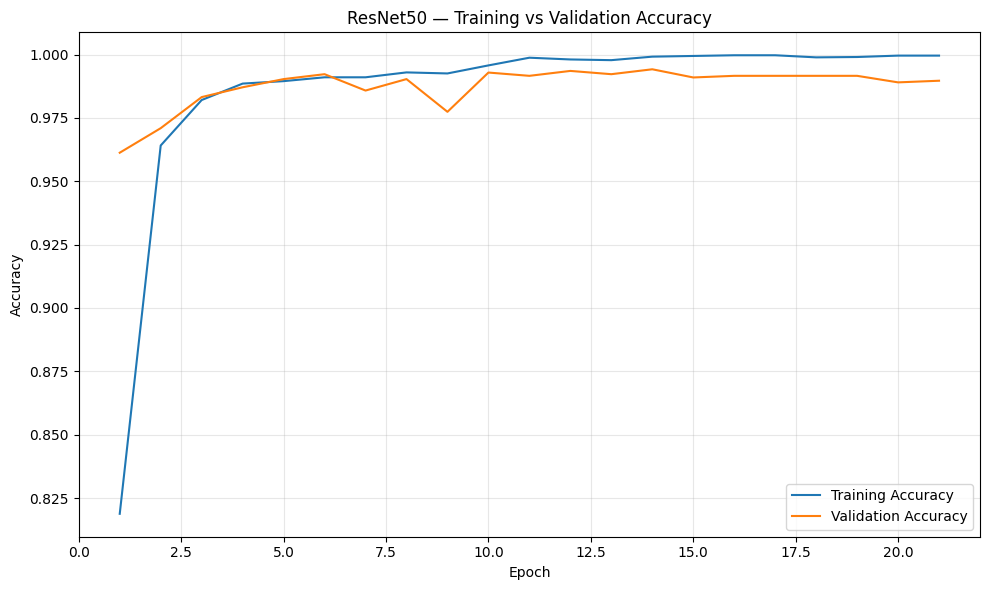

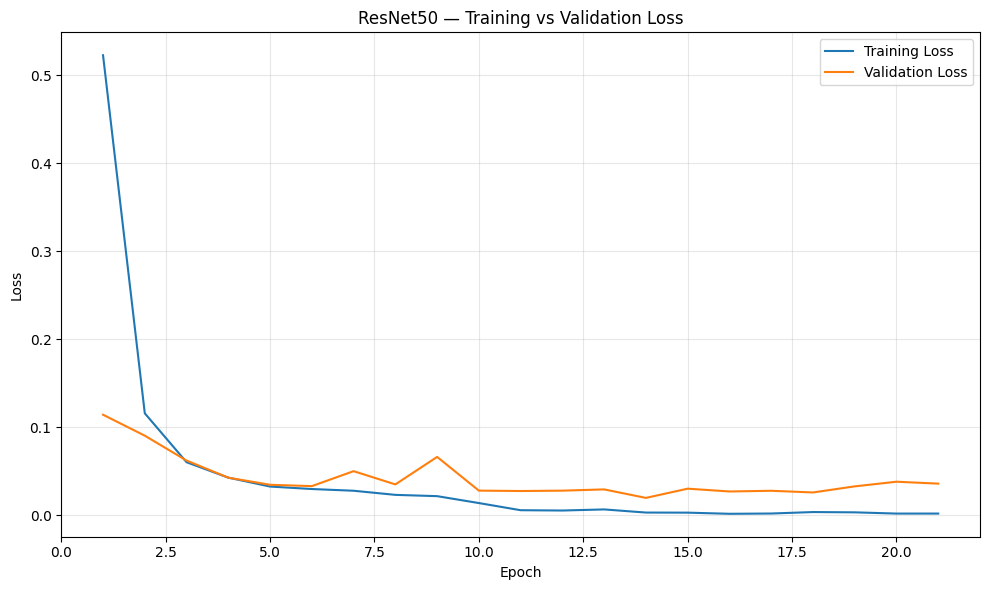


✓ Accuracy curve saved:
/kaggle/working/waste_model_results/resnet50_accuracy_curve.png

✓ Loss curve saved:
/kaggle/working/waste_model_results/resnet50_loss_curve.png


In [56]:
plot_training_curves(
    resnet50_history,
    "ResNet50",
    OUTPUT_DIR
)

# ## #  TEST DOMAIN COVERAGE AUDIT

In [57]:
# ============================================================
# TEST DOMAIN AUDIT — FIND THE 264 UNMAPPED IMAGES
# ============================================================

print("=" * 80)
print("TEST DOMAIN / SOURCE COLUMN AUDIT")
print("=" * 80)

print("\nTEST COLUMNS:")
for col in test_df.columns:
    print(" -", col)

print("\n" + "=" * 80)

# Show likely source/domain columns
possible_cols = [
    "source",
    "dataset",
    "domain",
    "country",
    "origin",
    "source_dataset",
    "dataset_source",
    "collection",
    "category"
]

for col in possible_cols:
    if col in test_df.columns:
        print(f"\nCOLUMN: {col}")
        print(test_df[col].value_counts(dropna=False))

TEST DOMAIN / SOURCE COLUMN AUDIT

TEST COLUMNS:
 - filename
 - class
 - source
 - country
 - dataset_group
 - original_path
 - image_path


COLUMN: source
source
International    1289
Bangladesh        585
Name: count, dtype: int64

COLUMN: country
country
International    1289
Bangladesh        585
Name: count, dtype: int64


In [58]:
# ============================================================
# FIND THE 264 UNMAPPED TEST IMAGES
# ============================================================

test_paths = set(test_df["original_path"])

bd_paths = set(bd_test["original_path"])
intl_paths = set(international_test_df["original_path"])

domain_union = bd_paths | intl_paths

unmapped_paths = test_paths - domain_union

unmapped_df = test_df[
    test_df["original_path"].isin(unmapped_paths)
].copy()

print("=" * 80)
print("UNMAPPED TEST IMAGES")
print("=" * 80)

print("Unmapped:", len(unmapped_df))

display(unmapped_df.head(20))

print("\nColumns:")
print(unmapped_df.columns.tolist())

UNMAPPED TEST IMAGES
Unmapped: 264


,filename,class,source,country,dataset_group,original_path,image_path
4,BD__EWaste__train__IMG_20250805_204652_jpg.rf....,Plastic,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Plasti...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
6,BD__AWaste__AWaste_Paper_20241130_181613.jpg,Paper,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Paper/...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
12,BD__EWaste__valid__IMG_20250822_141152_jpg.rf....,Metal,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Metal/...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
35,BD__BDWaste__BDWaste_Pastic__000094.jpg,Plastic,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Plasti...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
41,BD__EWaste__train__IMG_20250822_140600_1_jpg.r...,Paper,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Paper/...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
45,BD__BDWaste__BDWaste_Bottle__000098.jpg,Plastic,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Plasti...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
47,BD__EWaste__train__IMG_20250805_203121_jpg.rf....,Metal,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Metal/...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
49,BD__AWaste__AWaste_Paper_20250419_234000.jpg,Paper,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Paper/...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
52,BD__EWaste__train__IMG_20250803_221235_jpg.rf....,Metal,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Metal/...,/kaggle/input/notebooks/kbmhkhan/full-final-da...
53,BD__AWaste__AWaste_Glass_IMG_2137.JPG,Glass,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Glass/...,/kaggle/input/notebooks/kbmhkhan/full-final-da...



Columns:
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path', 'image_path']


In [59]:
# ============================================================
# INSPECT UNMAPPED IMAGE SOURCES
# ============================================================

for col in unmapped_df.columns:

    if col in [
        "original_path",
        "image_path"
    ]:
        continue

    print("\n" + "-" * 60)
    print("COLUMN:", col)
    print("-" * 60)

    try:
        print(
            unmapped_df[col]
            .value_counts(dropna=False)
            .head(30)
        )
    except:
        pass


------------------------------------------------------------
COLUMN: filename
------------------------------------------------------------
filename
BD__EWaste__train__IMG_20250803_221008_jpg.rf.24aa80e898b745bd985589f57eee71f2__obj0.jpg      1
BD__EWaste__train__IMG_20250805_204652_jpg.rf.ca65f300923a53f870cd47176cc88be0__obj0.jpg      1
BD__AWaste__AWaste_Paper_20241130_181613.jpg                                                  1
BD__EWaste__valid__IMG_20250822_141152_jpg.rf.55ac8b24a683a0bf4164cb577c94d795__obj0.jpg      1
BD__BDWaste__BDWaste_Pastic__000094.jpg                                                       1
BD__EWaste__train__IMG_20250822_140600_1_jpg.rf.a990e44f023870dd3f34045da432dc82__obj0.jpg    1
BD__BDWaste__BDWaste_Bottle__000098.jpg                                                       1
BD__EWaste__train__IMG_20250805_203121_jpg.rf.e31375d62004c5da8d8d1ed2bebd1f08__obj0.jpg      1
BD__EWaste__train__IMG_20250820_000400_jpg.rf.9dfc1e7b2c458ca9f435cc1beae14b08__obj

In [60]:
# ============================================================
# STEP 9 — CORRECT TEST DOMAIN SPLIT
# ============================================================

print("=" * 80)
print("CORRECTING TEST DOMAIN DEFINITIONS")
print("=" * 80)

# ------------------------------------------------------------
# FULL BANGLADESH TEST
# ------------------------------------------------------------

bd_test_complete = test_df[
    test_df["source"].astype(str).str.strip().str.lower()
    == "bangladesh"
].copy()

# ------------------------------------------------------------
# FULL INTERNATIONAL TEST
# ------------------------------------------------------------

intl_test_complete = test_df[
    test_df["source"].astype(str).str.strip().str.lower()
    == "international"
].copy()

print("Overall Test          :", len(test_df))
print("Bangladesh Test       :", len(bd_test_complete))
print("International Test    :", len(intl_test_complete))
print(
    "Domain Total          :",
    len(bd_test_complete) + len(intl_test_complete)
)

assert len(test_df) == 1874
assert len(bd_test_complete) == 585
assert len(intl_test_complete) == 1289

assert (
    len(bd_test_complete)
    + len(intl_test_complete)
    == len(test_df)
)

# ------------------------------------------------------------
# PATH OVERLAP
# ------------------------------------------------------------

bd_paths = set(
    bd_test_complete["original_path"]
)

intl_paths = set(
    intl_test_complete["original_path"]
)

test_paths = set(
    test_df["original_path"]
)

assert len(bd_paths & intl_paths) == 0

assert len(bd_paths & test_paths) == 585
assert len(intl_paths & test_paths) == 1289

assert len(
    bd_paths | intl_paths
) == 1874

print("\n✓ Bangladesh + International = full test set")
print("✓ No domain overlap")
print("✓ Domain accounting is correct")

CORRECTING TEST DOMAIN DEFINITIONS
Overall Test          : 1874
Bangladesh Test       : 585
International Test    : 1289
Domain Total          : 1874

✓ Bangladesh + International = full test set
✓ No domain overlap
✓ Domain accounting is correct


In [61]:
# ============================================================
# STEP 10 — CORRECT DOMAIN DATASETS / LOADERS
# ============================================================

bd_test_complete_dataset = WasteDataset(
    bd_test_complete,
    transform=eval_transform
)

intl_test_complete_dataset = WasteDataset(
    intl_test_complete,
    transform=eval_transform
)

bd_test_complete_loader = DataLoader(
    bd_test_complete_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

intl_test_complete_loader = DataLoader(
    intl_test_complete_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 80)
print("CORRECT DOMAIN LOADERS")
print("=" * 80)

print(
    "Bangladesh Test       :",
    len(bd_test_complete_dataset)
)

print(
    "International Test    :",
    len(intl_test_complete_dataset)
)

CORRECT DOMAIN LOADERS
Bangladesh Test       : 585
International Test    : 1289


In [62]:
# ============================================================
# STEP 11 — RESNET50 CORRECT DOMAIN EVALUATION
# ============================================================

resnet50_overall = evaluate_model(
    resnet50_final,
    test_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_bd_complete = evaluate_model(
    resnet50_final,
    bd_test_complete_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_int_complete = evaluate_model(
    resnet50_final,
    intl_test_complete_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — CORRECT FINAL DOMAIN EVALUATION")
print("=" * 80)

print("\nOverall Test")
print(
    f"Accuracy  : {resnet50_overall['accuracy']:.4f}"
)
print(
    f"Precision : {resnet50_overall['precision']:.4f}"
)
print(
    f"Recall    : {resnet50_overall['recall']:.4f}"
)
print(
    f"F1        : {resnet50_overall['f1']:.4f}"
)

print("\nBangladesh Test — COMPLETE")
print(
    f"Accuracy  : {resnet50_bd_complete['accuracy']:.4f}"
)
print(
    f"Precision : {resnet50_bd_complete['precision']:.4f}"
)
print(
    f"Recall    : {resnet50_bd_complete['recall']:.4f}"
)
print(
    f"F1        : {resnet50_bd_complete['f1']:.4f}"
)

print("\nInternational Test — COMPLETE")
print(
    f"Accuracy  : {resnet50_int_complete['accuracy']:.4f}"
)
print(
    f"Precision : {resnet50_int_complete['precision']:.4f}"
)
print(
    f"Recall    : {resnet50_int_complete['recall']:.4f}"
)
print(
    f"F1        : {resnet50_int_complete['f1']:.4f}"
)

RESNET50 — CORRECT FINAL DOMAIN EVALUATION

Overall Test
Accuracy  : 0.9941
Precision : 0.9942
Recall    : 0.9941
F1        : 0.9941

Bangladesh Test — COMPLETE
Accuracy  : 0.9880
Precision : 0.9882
Recall    : 0.9880
F1        : 0.9881

International Test — COMPLETE
Accuracy  : 0.9969
Precision : 0.9969
Recall    : 0.9969
F1        : 0.9969


# ## #  RESNET50 DOMAIN RESULTS TABLE

In [63]:
# ============================================================
# STEP 12 — RESNET50 DOMAIN RESULTS TABLE
# ============================================================

resnet50_domain_results = pd.DataFrame([
    {
        "Dataset": "Overall Test",
        "Samples": len(test_dataset),
        "Accuracy": resnet50_overall["accuracy"],
        "Precision": resnet50_overall["precision"],
        "Recall": resnet50_overall["recall"],
        "F1": resnet50_overall["f1"]
    },
    {
        "Dataset": "Bangladesh Test",
        "Samples": len(bd_test_complete_dataset),
        "Accuracy": resnet50_bd_complete["accuracy"],
        "Precision": resnet50_bd_complete["precision"],
        "Recall": resnet50_bd_complete["recall"],
        "F1": resnet50_bd_complete["f1"]
    },
    {
        "Dataset": "International Test",
        "Samples": len(intl_test_complete_dataset),
        "Accuracy": resnet50_int_complete["accuracy"],
        "Precision": resnet50_int_complete["precision"],
        "Recall": resnet50_int_complete["recall"],
        "F1": resnet50_int_complete["f1"]
    }
])

display(
    resnet50_domain_results.style.format({
        "Accuracy": "{:.4%}",
        "Precision": "{:.4%}",
        "Recall": "{:.4%}",
        "F1": "{:.4%}"
    })
)

resnet50_domain_results.to_csv(
    OUTPUT_DIR / "resnet50_domain_results.csv",
    index=False
)

print("\n✓ Domain results saved")

,Dataset,Samples,Accuracy,Precision,Recall,F1
0,Overall Test,1874,99.4130%,99.4160%,99.4130%,99.4132%
1,Bangladesh Test,585,98.8034%,98.8205%,98.8034%,98.8050%
2,International Test,1289,99.6897%,99.6919%,99.6897%,99.6897%



✓ Domain results saved


# ## # #  Confusion Matrix

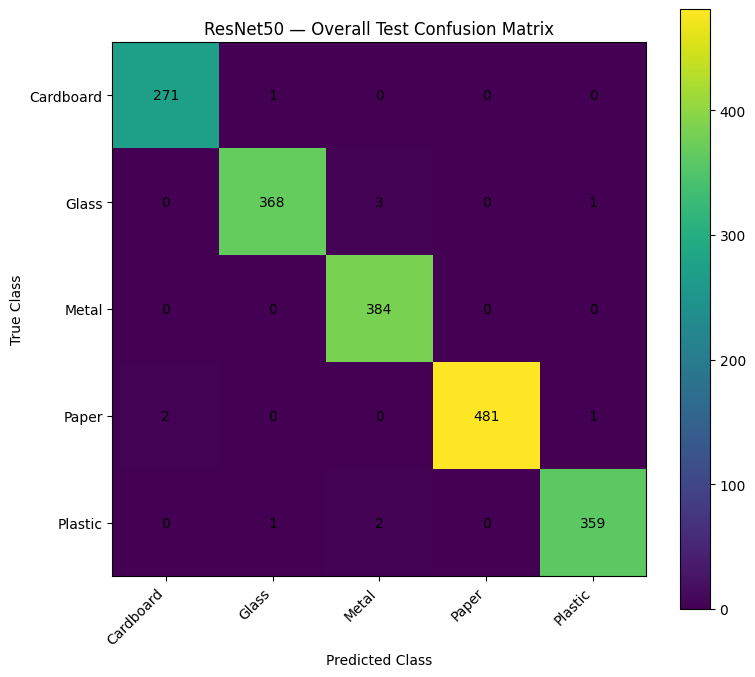

✓ Saved: /kaggle/working/waste_model_results/resnet50_confusion_matrix.png


In [64]:
# ============================================================
# STEP 13 — RESNET50 CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    resnet50_overall["labels"],
    resnet50_overall["predictions"]
)

plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    "ResNet50 — Overall Test Confusion Matrix"
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

cm_path = (
    OUTPUT_DIR /
    "resnet50_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", cm_path)

# ## # # #  NORMALIZED CONFUSION MATRIX

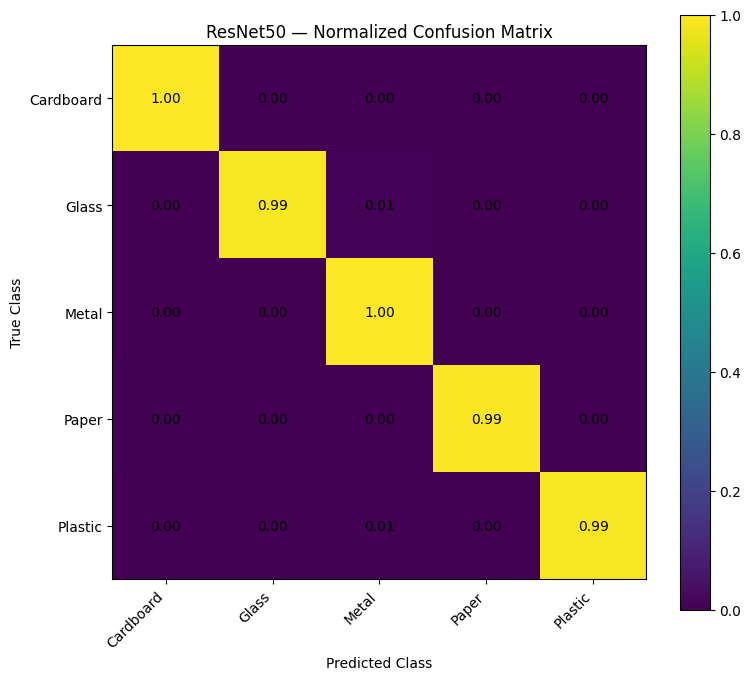

✓ Saved: /kaggle/working/waste_model_results/resnet50_normalized_confusion_matrix.png


In [65]:
# ============================================================
# STEP 14 — NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = cm.astype(float) / cm.sum(
    axis=1,
    keepdims=True
)

plt.figure(figsize=(8, 7))

plt.imshow(
    cm_normalized,
    vmin=0,
    vmax=1
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    "ResNet50 — Normalized Confusion Matrix"
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

normalized_cm_path = (
    OUTPUT_DIR /
    "resnet50_normalized_confusion_matrix.png"
)

plt.savefig(
    normalized_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", normalized_cm_path)

# ## # # #  Per-class report

In [66]:
# ============================================================
# STEP 15 — RESNET50 CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    resnet50_overall["labels"],
    resnet50_overall["predictions"],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

resnet50_class_report = pd.DataFrame(
    report
).transpose()

display(
    resnet50_class_report.style.format(
        "{:.4f}"
    )
)

resnet50_class_report.to_csv(
    OUTPUT_DIR /
    "resnet50_classification_report.csv"
)

print("✓ Classification report saved")

,precision,recall,f1-score,support
Cardboard,0.9927,0.9963,0.9945,272.0000
Glass,0.9946,0.9892,0.9919,372.0000
Metal,0.9871,1.0000,0.9935,384.0000
Paper,1.0000,0.9938,0.9969,484.0000
Plastic,0.9945,0.9917,0.9931,362.0000
accuracy,0.9941,0.9941,0.9941,0.9941
macro avg,0.9938,0.9942,0.9940,1874.0000
weighted avg,0.9942,0.9941,0.9941,1874.0000


✓ Classification report saved


# ## # #  RESNET50 HISTORY COLUMN INSPECTION

In [67]:
# ============================================================
# FIX — RESNET50 HISTORY COLUMN INSPECTION
# ============================================================

print("=" * 80)
print("RESNET50 HISTORY COLUMNS")
print("=" * 80)

print(resnet50_history.columns.tolist())

display(resnet50_history.head())

RESNET50 HISTORY COLUMNS
['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate', 'epoch_time']


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,epoch_time
0,1,0.522607,0.818772,0.114398,0.961265,0.0001,126.591281
1,2,0.116002,0.964113,0.090606,0.970949,0.0001,127.078542
2,3,0.060466,0.982057,0.062356,0.983215,0.0001,126.652178
3,4,0.042928,0.988544,0.042909,0.987088,0.0001,126.321071
4,5,0.032829,0.989510,0.034824,0.990316,0.0001,129.304326


# ## # # #  ROBUST TRAINING VISUALIZATION

In [68]:
# ============================================================
# ROBUST TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path


def find_history_column(df, candidates):

    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f"None of these columns found: {candidates}\n"
        f"Available columns: {df.columns.tolist()}"
    )


def plot_training_curves(
    history_df,
    model_name,
    experiment_name="baseline"
):

    epoch_col = find_history_column(
        history_df,
        [
            "epoch",
            "Epoch"
        ]
    )

    train_acc_col = find_history_column(
        history_df,
        [
            "train_acc",
            "train_accuracy",
            "Train Acc",
            "train_accuarcy"
        ]
    )

    val_acc_col = find_history_column(
        history_df,
        [
            "val_acc",
            "val_accuracy",
            "Validation Acc",
            "valid_acc"
        ]
    )

    train_loss_col = find_history_column(
        history_df,
        [
            "train_loss",
            "Train Loss"
        ]
    )

    val_loss_col = find_history_column(
        history_df,
        [
            "val_loss",
            "Validation Loss"
        ]
    )

    epochs = history_df[epoch_col]

    save_prefix = (
        f"{model_name.lower()}_"
        f"{experiment_name.lower().replace(' ', '_')}"
    )

    # ========================================================
    # ACCURACY
    # ========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        history_df[train_acc_col],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history_df[val_acc_col],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{model_name} — {experiment_name} Accuracy"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    path = (
        OUTPUT_DIR /
        f"{save_prefix}_accuracy.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # LOSS
    # ========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        history_df[train_loss_col],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history_df[val_loss_col],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{model_name} — {experiment_name} Loss"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    path = (
        OUTPUT_DIR /
        f"{save_prefix}_loss.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"✓ Accuracy curve saved: {save_prefix}_accuracy.png"
    )

    print(
        f"✓ Loss curve saved: {save_prefix}_loss.png"
    )

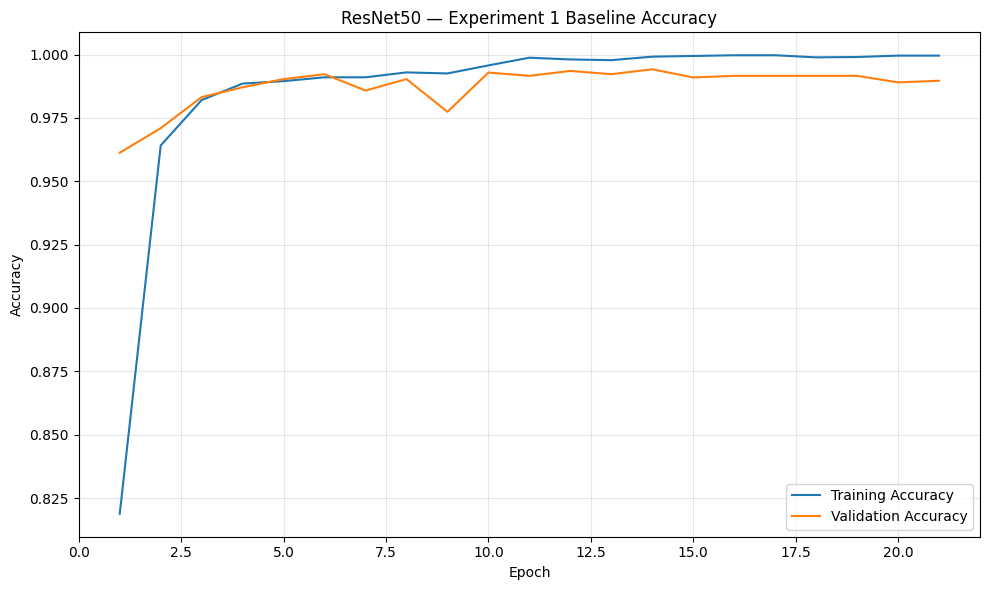

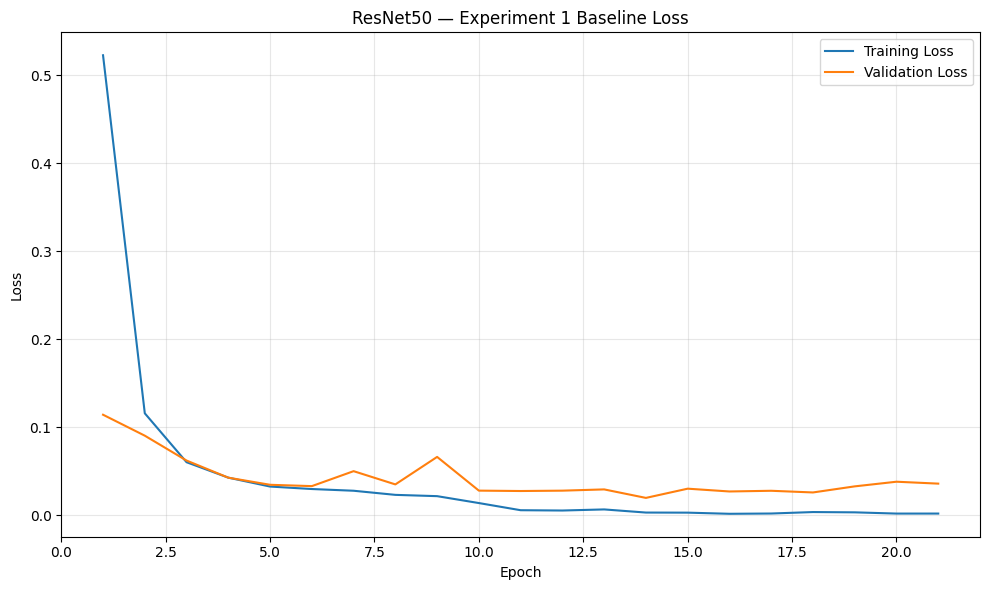

✓ Accuracy curve saved: resnet50_experiment_1_baseline_accuracy.png
✓ Loss curve saved: resnet50_experiment_1_baseline_loss.png


In [69]:
plot_training_curves(
    resnet50_history,
    "ResNet50",
    "Experiment 1 Baseline"
)

In [70]:
# ============================================================
# RESNET50 — FINAL BEST CHECKPOINT
# ============================================================

resnet50_final = create_model(
    "resnet50",
    NUM_CLASSES
)

checkpoint_path = (
    CHECKPOINT_DIR /
    "resnet50_best.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint


resnet50_final.load_state_dict(
    state_dict
)

resnet50_final = resnet50_final.to(
    DEVICE
)

resnet50_final.eval()

print("=" * 80)
print("RESNET50 BEST MODEL READY")
print("=" * 80)

print("Checkpoint:", checkpoint_path)
print("Device:", DEVICE)

print("\n✓ Best ResNet50 checkpoint loaded")
print("✓ Model ready for experiments")

RESNET50 BEST MODEL READY
Checkpoint: /kaggle/working/waste_model_results/checkpoints/resnet50_best.pth
Device: cuda

✓ Best ResNet50 checkpoint loaded
✓ Model ready for experiments


# ## # #  RESNET50 EXPERIMENT FRAMEWORK

In [71]:
# ============================================================
# STEP 16 — RESNET50 EXPERIMENT FRAMEWORK
# ============================================================

import os
import gc
import time
import copy
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RESNET_EXP_DIR = OUTPUT_DIR / "resnet50_experiments"
RESNET_EXP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for exp_name in [
    "E1_baseline",
    "E2_strong_augmentation",
    "E3_adamw_cosine",
    "E4_label_smoothing",
    "E5_high_resolution"
]:
    (RESNET_EXP_DIR / exp_name).mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 80)
print("RESNET50 EXPERIMENT FRAMEWORK READY")
print("=" * 80)
print("Experiments: 5")
print("E1: Baseline")
print("E2: Strong Augmentation")
print("E3: AdamW + Cosine")
print("E4: Label Smoothing")
print("E5: 256x256 Resolution")

RESNET50 EXPERIMENT FRAMEWORK READY
Experiments: 5
E1: Baseline
E2: Strong Augmentation
E3: AdamW + Cosine
E4: Label Smoothing
E5: 256x256 Resolution


# ## # # #  RESEARCH-GRADE TRAINING FUNCTION

In [72]:
# ============================================================
# STEP 17 — RESEARCH-GRADE TRAINING FUNCTION
# ============================================================

def train_experiment(
    model_name,
    experiment_name,
    train_loader_exp,
    val_loader_exp,
    epochs=30,
    lr=1e-4,
    weight_decay=1e-4,
    optimizer_type="adam",
    scheduler_type="plateau",
    label_smoothing=0.0
):

    print("\n" + "=" * 80)
    print(f"TRAINING: {model_name.upper()} — {experiment_name}")
    print("=" * 80)

    model = create_model(
        model_name,
        NUM_CLASSES
    ).to(DEVICE)

    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss(
        label_smoothing=label_smoothing
    )

    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    if optimizer_type.lower() == "adam":

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    elif optimizer_type.lower() == "adamw":

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    else:
        raise ValueError(
            f"Unknown optimizer: {optimizer_type}"
        )

    # --------------------------------------------------------
    # SCHEDULER
    # --------------------------------------------------------

    if scheduler_type == "plateau":

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=3
        )

    elif scheduler_type == "cosine":

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs
        )

    elif scheduler_type == "none":

        scheduler = None

    else:

        raise ValueError(
            f"Unknown scheduler: {scheduler_type}"
        )

    # --------------------------------------------------------
    # EXPERIMENT DIRECTORY
    # --------------------------------------------------------

    exp_dir = (
        RESNET_EXP_DIR /
        experiment_name
    )

    exp_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    checkpoint_path = (
        exp_dir /
        f"{model_name}_best.pth"
    )

    history = []

    best_val_acc = -1.0
    best_epoch = 0
    best_state = None

    patience_counter = 0
    patience = PATIENCE

    start_time = time.time()

    # --------------------------------------------------------
    # TRAINING LOOP
    # --------------------------------------------------------

    for epoch in range(1, epochs + 1):

        epoch_start = time.time()

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader_exp:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = (
            running_loss / total
        )

        train_acc = (
            correct / total
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader_exp:

                images = images.to(
                    DEVICE,
                    non_blocking=True
                )

                labels = labels.to(
                    DEVICE,
                    non_blocking=True
                )

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_loss_total += (
                    loss.item()
                    * images.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_loss = (
            val_loss_total / val_total
        )

        val_acc = (
            val_correct / val_total
        )

        # ----------------------------------------------------
        # SCHEDULER
        # ----------------------------------------------------

        if scheduler_type == "plateau":

            scheduler.step(
                val_acc
            )

        elif scheduler_type == "cosine":

            scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        epoch_time = (
            time.time()
            - epoch_start
        )

        history.append({

            "epoch": epoch,

            "train_loss": train_loss,

            "train_accuracy": train_acc,

            "val_loss": val_loss,

            "val_accuracy": val_acc,

            "learning_rate": current_lr,

            "epoch_time": epoch_time

        })

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        # ----------------------------------------------------
        # BEST CHECKPOINT
        # ----------------------------------------------------

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                {
                    "model_name": model_name,
                    "experiment": experiment_name,
                    "epoch": epoch,
                    "val_accuracy": val_acc,
                    "model_state_dict": best_state
                },
                checkpoint_path
            )

            patience_counter = 0

            print(
                f"  ✓ Best checkpoint saved "
                f"(Val Acc: {val_acc:.4f})"
            )

        else:

            patience_counter += 1

        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if patience_counter >= patience:

            print(
                f"\nEarly stopping at epoch {epoch}"
            )

            break

    total_time = (
        time.time()
        - start_time
    )

    # --------------------------------------------------------
    # RESTORE BEST
    # --------------------------------------------------------

    model.load_state_dict(
        best_state
    )

    history_df = pd.DataFrame(
        history
    )

    history_path = (
        exp_dir /
        "history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    # --------------------------------------------------------
    # CONFIG
    # --------------------------------------------------------

    config = {

        "model": model_name,

        "experiment": experiment_name,

        "epochs": epochs,

        "learning_rate": lr,

        "weight_decay": weight_decay,

        "optimizer": optimizer_type,

        "scheduler": scheduler_type,

        "label_smoothing": label_smoothing,

        "batch_size": BATCH_SIZE,

        "image_size": IMG_SIZE,

        "seed": SEED,

        "best_epoch": best_epoch,

        "best_validation_accuracy": best_val_acc,

        "training_minutes": total_time / 60

    }

    with open(
        exp_dir / "config.json",
        "w"
    ) as f:

        json.dump(
            config,
            f,
            indent=4
        )

    print("\n" + "-" * 80)

    print(
        f"Best validation accuracy: "
        f"{best_val_acc:.4f}"
    )

    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Training time: "
        f"{total_time / 60:.2f} minutes"
    )

    print(
        f"Checkpoint: "
        f"{checkpoint_path}"
    )

    return model, history_df, config

# ## # #  RESEARCH TRAINING VISUALIZATION

In [73]:
# ============================================================
# STEP 18 — RESEARCH TRAINING VISUALIZATION
# ============================================================

def visualize_experiment(
    history_df,
    model_name,
    experiment_name,
    output_dir
):

    exp_dir = (
        output_dir /
        experiment_name
    )

    exp_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    epochs = history_df["epoch"]

    # ========================================================
    # ACCURACY
    # ========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        history_df["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history_df["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{model_name} — {experiment_name}\nAccuracy"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    accuracy_path = (
        exp_dir /
        "accuracy_curve.png"
    )

    plt.savefig(
        accuracy_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # LOSS
    # ========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        history_df["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history_df["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{model_name} — {experiment_name}\nLoss"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    loss_path = (
        exp_dir /
        "loss_curve.png"
    )

    plt.savefig(
        loss_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # LEARNING RATE
    # ========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        history_df["learning_rate"]
    )

    plt.xlabel("Epoch")

    plt.ylabel(
        "Learning Rate"
    )

    plt.title(
        f"{model_name} — {experiment_name}\nLearning Rate"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    lr_path = (
        exp_dir /
        "learning_rate_curve.png"
    )

    plt.savefig(
        lr_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"✓ Saved visualization for "
        f"{experiment_name}"
    )

# ## # #  RESNET50 E2 STRONG AUGMENTATION

In [74]:
# ============================================================
# STEP 19 — RESNET50 E2 STRONG AUGMENTATION
# ============================================================

IMG_SIZE = 224

strong_train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.15
    ),

    transforms.RandomRotation(
        degrees=20
    ),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.80, 1.0),
        ratio=(0.90, 1.10)
    ),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.20,
        hue=0.05
    ),

    transforms.RandomGrayscale(
        p=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

strong_train_dataset = WasteDataset(
    train_df,
    transform=strong_train_transform
)

strong_train_loader = DataLoader(
    strong_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 80)
print("E2 — STRONG AUGMENTATION READY")
print("=" * 80)

E2 — STRONG AUGMENTATION READY


# ## # # #  RESNET50 — EXPERIMENT 2

In [75]:
# ============================================================
# RESNET50 — EXPERIMENT 2
# ============================================================

resnet50_e2_model, resnet50_e2_history, resnet50_e2_config = \
    train_experiment(
        model_name="resnet50",

        experiment_name="E2_strong_augmentation",

        train_loader_exp=strong_train_loader,

        val_loader_exp=val_loader,

        epochs=30,

        lr=1e-4,

        weight_decay=1e-4,

        optimizer_type="adam",

        scheduler_type="plateau",

        label_smoothing=0.0
    )

print(
    "\n✓ RESNET50 E2 COMPLETE"
)


TRAINING: RESNET50 — E2_strong_augmentation
Epoch 01/30 | Train Loss: 0.6317 | Train Acc: 0.7727 | Val Loss: 0.1709 | Val Acc: 0.9425 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9425)
Epoch 02/30 | Train Loss: 0.1914 | Train Acc: 0.9364 | Val Loss: 0.0816 | Val Acc: 0.9729 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9729)
Epoch 03/30 | Train Loss: 0.1275 | Train Acc: 0.9575 | Val Loss: 0.0733 | Val Acc: 0.9729 | LR: 1.00e-04
Epoch 04/30 | Train Loss: 0.0854 | Train Acc: 0.9728 | Val Loss: 0.0487 | Val Acc: 0.9832 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9832)
Epoch 05/30 | Train Loss: 0.0717 | Train Acc: 0.9757 | Val Loss: 0.0368 | Val Acc: 0.9877 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9877)
Epoch 06/30 | Train Loss: 0.0525 | Train Acc: 0.9819 | Val Loss: 0.0498 | Val Acc: 0.9826 | LR: 1.00e-04
Epoch 07/30 | Train Loss: 0.0577 | Train Acc: 0.9816 | Val Loss: 0.0326 | Val Acc: 0.9884 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9884)


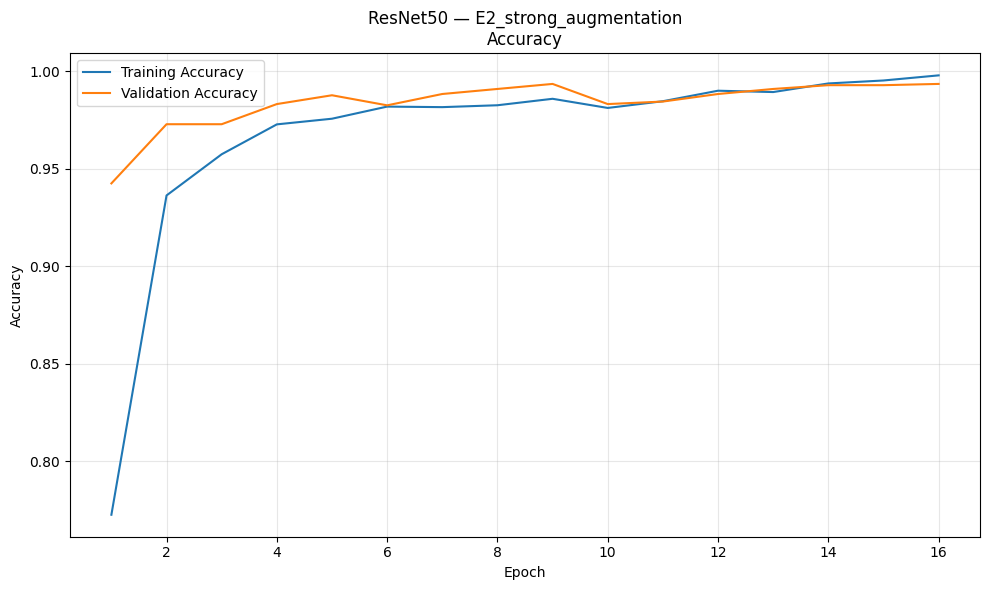

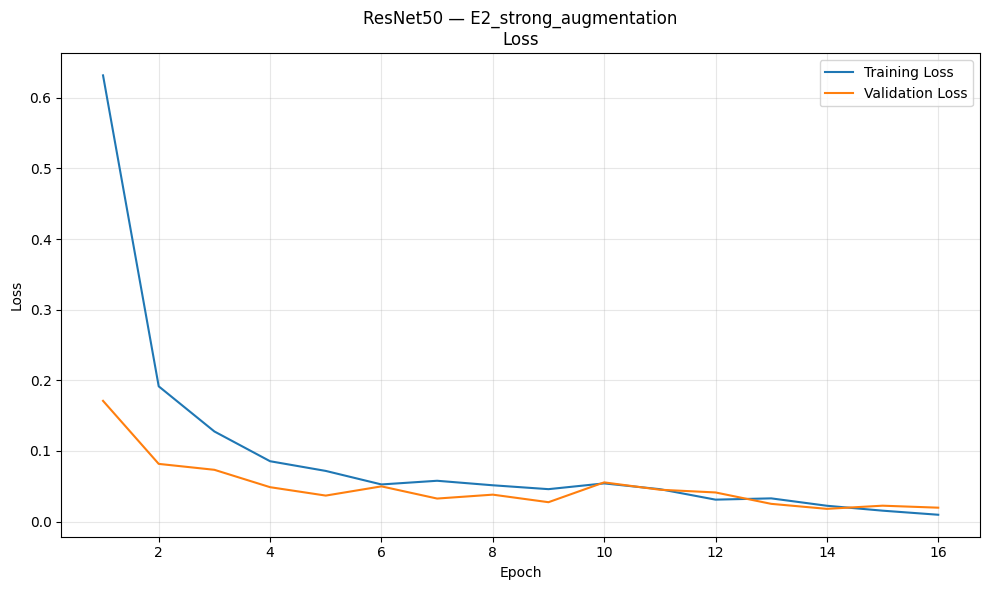

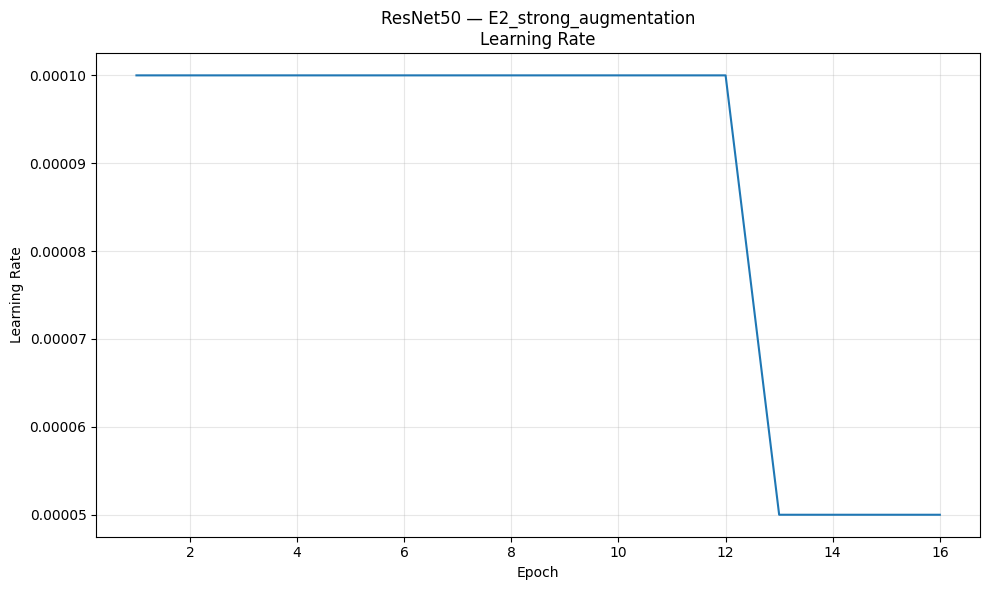

✓ Saved visualization for E2_strong_augmentation


In [76]:
visualize_experiment(
    resnet50_e2_history,
    "ResNet50",
    "E2_strong_augmentation",
    RESNET_EXP_DIR
)

# ## # #  E2 — TEST EVALUATION

In [77]:
# ============================================================
# E2 — TEST EVALUATION
# ============================================================

resnet50_e2_overall = evaluate_model(
    resnet50_e2_model,
    test_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_e2_bd = evaluate_model(
    resnet50_e2_model,
    bd_test_complete_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_e2_int = evaluate_model(
    resnet50_e2_model,
    intl_test_complete_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — E2 RESULTS")
print("=" * 80)

print(
    f"Overall       : "
    f"{resnet50_e2_overall['accuracy']:.4%}"
)

print(
    f"Bangladesh    : "
    f"{resnet50_e2_bd['accuracy']:.4%}"
)

print(
    f"International : "
    f"{resnet50_e2_int['accuracy']:.4%}"
)

RESNET50 — E2 RESULTS
Overall       : 98.2391%
Bangladesh    : 95.3846%
International : 99.5345%


# ## # #  E2 CONFUSION MATRIX

In [78]:
# ============================================================
# E2 CONFUSION MATRIX
# ============================================================

def save_confusion_matrix(
    results,
    model_name,
    experiment_name,
    output_dir,
    normalized=False
):

    cm = confusion_matrix(
        results["labels"],
        results["predictions"]
    )

    if normalized:

        cm_plot = (
            cm.astype(float)
            /
            cm.sum(
                axis=1,
                keepdims=True
            )
        )

    else:

        cm_plot = cm

    plt.figure(figsize=(8, 7))

    plt.imshow(
        cm_plot,
        vmin=0 if normalized else None,
        vmax=1 if normalized else None
    )

    plt.colorbar()

    plt.xticks(
        range(NUM_CLASSES),
        CLASS_NAMES,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(NUM_CLASSES),
        CLASS_NAMES
    )

    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "True Class"
    )

    title = (
        f"{model_name} — "
        f"{experiment_name} — "
        f"{'Normalized ' if normalized else ''}"
        f"Confusion Matrix"
    )

    plt.title(title)

    for i in range(NUM_CLASSES):

        for j in range(NUM_CLASSES):

            if normalized:

                text = f"{cm_plot[i,j]:.2f}"

            else:

                text = str(cm_plot[i,j])

            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center"
            )

    plt.tight_layout()

    filename = (
        "confusion_matrix_normalized.png"
        if normalized
        else
        "confusion_matrix.png"
    )

    path = (
        output_dir /
        experiment_name /
        filename
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "✓ Saved:",
        path
    )

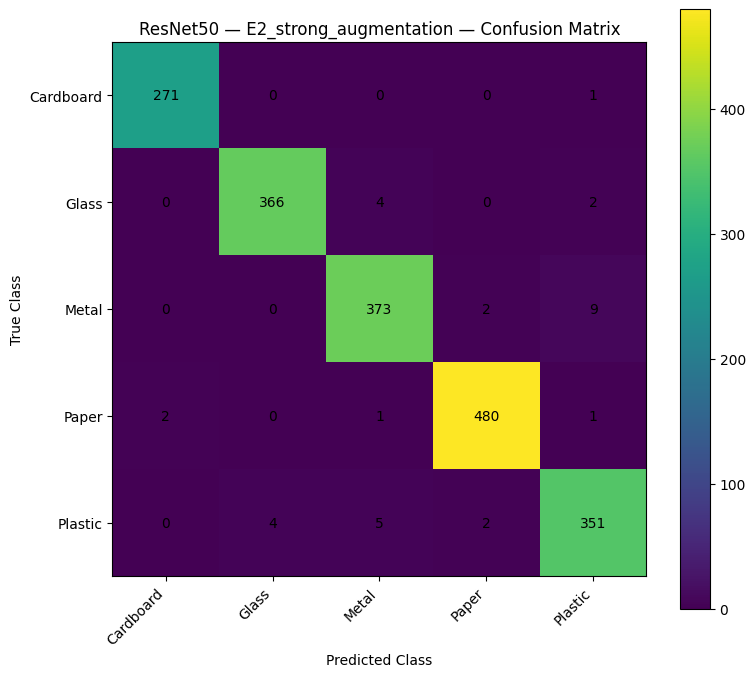

✓ Saved: /kaggle/working/waste_model_results/resnet50_experiments/E2_strong_augmentation/confusion_matrix.png


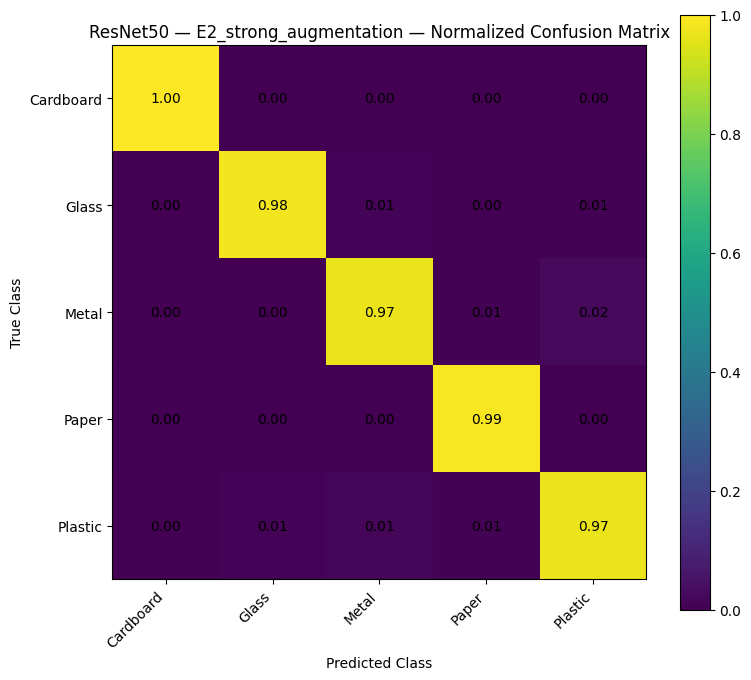

✓ Saved: /kaggle/working/waste_model_results/resnet50_experiments/E2_strong_augmentation/confusion_matrix_normalized.png


In [79]:
save_confusion_matrix(
    resnet50_e2_overall,
    "ResNet50",
    "E2_strong_augmentation",
    RESNET_EXP_DIR,
    normalized=False
)

save_confusion_matrix(
    resnet50_e2_overall,
    "ResNet50",
    "E2_strong_augmentation",
    RESNET_EXP_DIR,
    normalized=True
)

# ##   E2 CLASSIFICATION REPORT

In [80]:
# ============================================================
# E2 CLASSIFICATION REPORT
# ============================================================

def save_classification_report(
    results,
    model_name,
    experiment_name,
    output_dir
):

    report = classification_report(
        results["labels"],
        results["predictions"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(
        report
    ).transpose()

    display(
        report_df.style.format(
            "{:.4f}"
        )
    )

    path = (
        output_dir /
        experiment_name /
        "classification_report.csv"
    )

    report_df.to_csv(path)

    print(
        "✓ Saved:",
        path
    )

    return report_df


resnet50_e2_report = save_classification_report(
    resnet50_e2_overall,
    "ResNet50",
    "E2_strong_augmentation",
    RESNET_EXP_DIR
)

,precision,recall,f1-score,support
Cardboard,0.9927,0.9963,0.9945,272.0000
Glass,0.9892,0.9839,0.9865,372.0000
Metal,0.9739,0.9714,0.9726,384.0000
Paper,0.9917,0.9917,0.9917,484.0000
Plastic,0.9643,0.9696,0.9669,362.0000
accuracy,0.9824,0.9824,0.9824,0.9824
macro avg,0.9824,0.9826,0.9825,1874.0000
weighted avg,0.9824,0.9824,0.9824,1874.0000


✓ Saved: /kaggle/working/waste_model_results/resnet50_experiments/E2_strong_augmentation/classification_report.csv


# ## # #  RESNET50 — E3 ADAMW + COSINE

In [81]:
# ============================================================
# RESNET50 — E3 ADAMW + COSINE
# ============================================================

resnet50_e3_model, resnet50_e3_history, resnet50_e3_config = \
    train_experiment(

        model_name="resnet50",

        experiment_name="E3_adamw_cosine",

        train_loader_exp=train_loader,

        val_loader_exp=val_loader,

        epochs=30,

        lr=1e-4,

        weight_decay=1e-4,

        optimizer_type="adamw",

        scheduler_type="cosine",

        label_smoothing=0.0
    )

print(
    "\n✓ RESNET50 E3 COMPLETE"
)


TRAINING: RESNET50 — E3_adamw_cosine
Epoch 01/30 | Train Loss: 0.5405 | Train Acc: 0.8130 | Val Loss: 0.1441 | Val Acc: 0.9490 | LR: 9.97e-05
  ✓ Best checkpoint saved (Val Acc: 0.9490)
Epoch 02/30 | Train Loss: 0.1194 | Train Acc: 0.9622 | Val Loss: 0.0767 | Val Acc: 0.9755 | LR: 9.89e-05
  ✓ Best checkpoint saved (Val Acc: 0.9755)
Epoch 03/30 | Train Loss: 0.0616 | Train Acc: 0.9796 | Val Loss: 0.0400 | Val Acc: 0.9890 | LR: 9.76e-05
  ✓ Best checkpoint saved (Val Acc: 0.9890)
Epoch 04/30 | Train Loss: 0.0446 | Train Acc: 0.9855 | Val Loss: 0.0531 | Val Acc: 0.9852 | LR: 9.57e-05
Epoch 05/30 | Train Loss: 0.0269 | Train Acc: 0.9927 | Val Loss: 0.0433 | Val Acc: 0.9910 | LR: 9.33e-05
  ✓ Best checkpoint saved (Val Acc: 0.9910)
Epoch 06/30 | Train Loss: 0.0323 | Train Acc: 0.9912 | Val Loss: 0.0297 | Val Acc: 0.9923 | LR: 9.05e-05
  ✓ Best checkpoint saved (Val Acc: 0.9923)
Epoch 07/30 | Train Loss: 0.0245 | Train Acc: 0.9927 | Val Loss: 0.0356 | Val Acc: 0.9890 | LR: 8.72e-05
Epoch 0

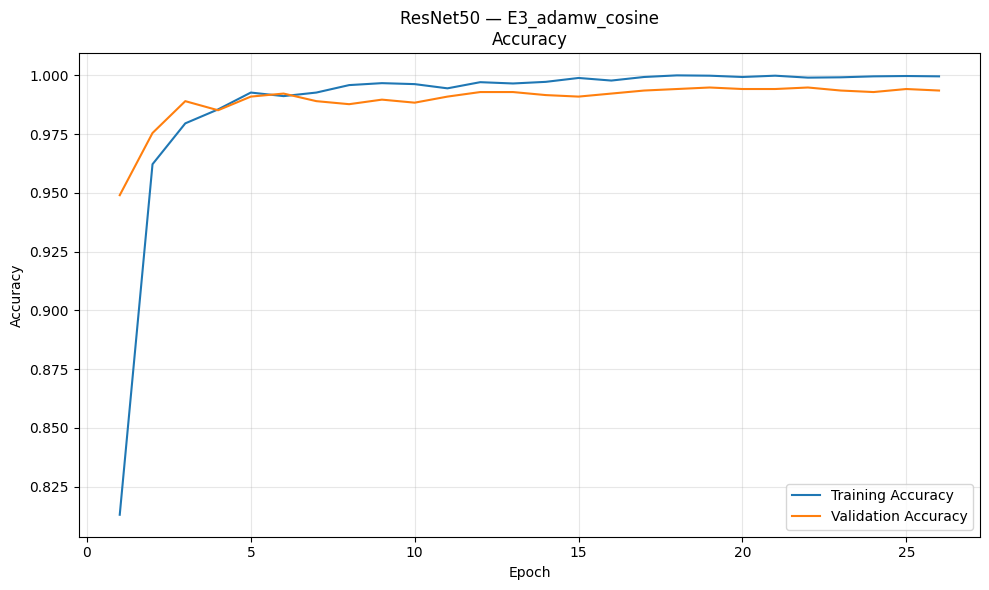

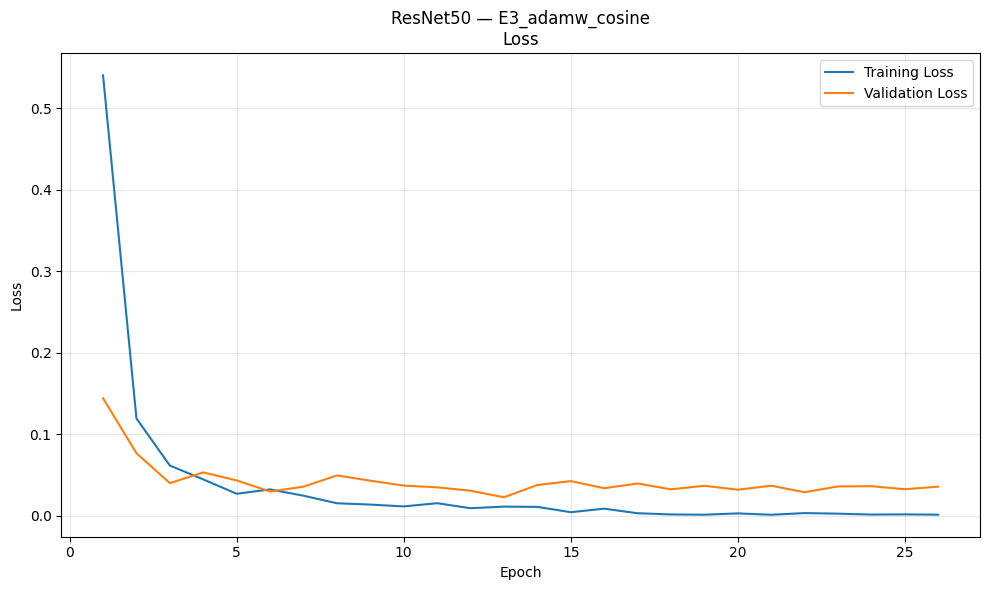

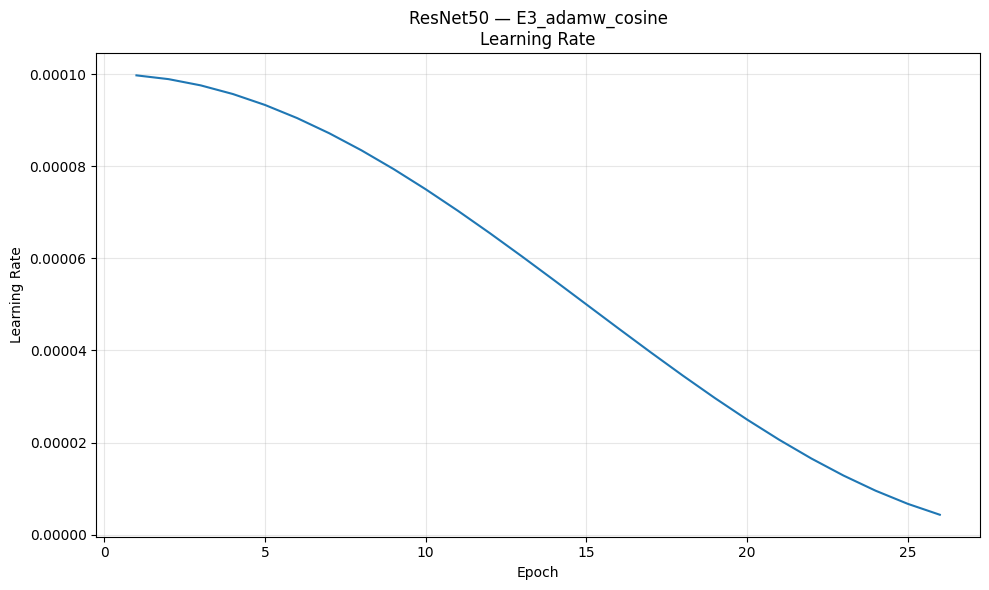

✓ Saved visualization for E3_adamw_cosine


In [82]:
visualize_experiment(
    resnet50_e3_history,
    "ResNet50",
    "E3_adamw_cosine",
    RESNET_EXP_DIR
)

In [83]:
resnet50_e3_overall = evaluate_model(
    resnet50_e3_model,
    test_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_e3_bd = evaluate_model(
    resnet50_e3_model,
    bd_test_complete_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_e3_int = evaluate_model(
    resnet50_e3_model,
    intl_test_complete_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — E3")
print("=" * 80)

print(
    f"Overall       : "
    f"{resnet50_e3_overall['accuracy']:.4%}"
)

print(
    f"Bangladesh    : "
    f"{resnet50_e3_bd['accuracy']:.4%}"
)

print(
    f"International : "
    f"{resnet50_e3_int['accuracy']:.4%}"
)

RESNET50 — E3
Overall       : 99.3597%
Bangladesh    : 98.2906%
International : 99.8448%


# ## #  RESNET50 — E4 LABEL SMOOTHING

In [84]:
# ============================================================
# RESNET50 — E4 LABEL SMOOTHING
# ============================================================

resnet50_e4_model, resnet50_e4_history, resnet50_e4_config = \
    train_experiment(

        model_name="resnet50",

        experiment_name="E4_label_smoothing",

        train_loader_exp=train_loader,

        val_loader_exp=val_loader,

        epochs=30,

        lr=1e-4,

        weight_decay=1e-4,

        optimizer_type="adam",

        scheduler_type="plateau",

        label_smoothing=0.1
    )

print(
    "\n✓ RESNET50 E4 COMPLETE"
)


TRAINING: RESNET50 — E4_label_smoothing
Epoch 01/30 | Train Loss: 0.7898 | Train Acc: 0.8115 | Val Loss: 0.4977 | Val Acc: 0.9600 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9600)
Epoch 02/30 | Train Loss: 0.4761 | Train Acc: 0.9728 | Val Loss: 0.4542 | Val Acc: 0.9748 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9748)
Epoch 03/30 | Train Loss: 0.4369 | Train Acc: 0.9881 | Val Loss: 0.4248 | Val Acc: 0.9897 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9897)
Epoch 04/30 | Train Loss: 0.4201 | Train Acc: 0.9943 | Val Loss: 0.4272 | Val Acc: 0.9897 | LR: 1.00e-04
Epoch 05/30 | Train Loss: 0.4178 | Train Acc: 0.9941 | Val Loss: 0.4176 | Val Acc: 0.9903 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9903)
Epoch 06/30 | Train Loss: 0.4121 | Train Acc: 0.9948 | Val Loss: 0.4220 | Val Acc: 0.9890 | LR: 1.00e-04
Epoch 07/30 | Train Loss: 0.4094 | Train Acc: 0.9943 | Val Loss: 0.4400 | Val Acc: 0.9781 | LR: 1.00e-04
Epoch 08/30 | Train Loss: 0.4076 | Train Acc: 0.

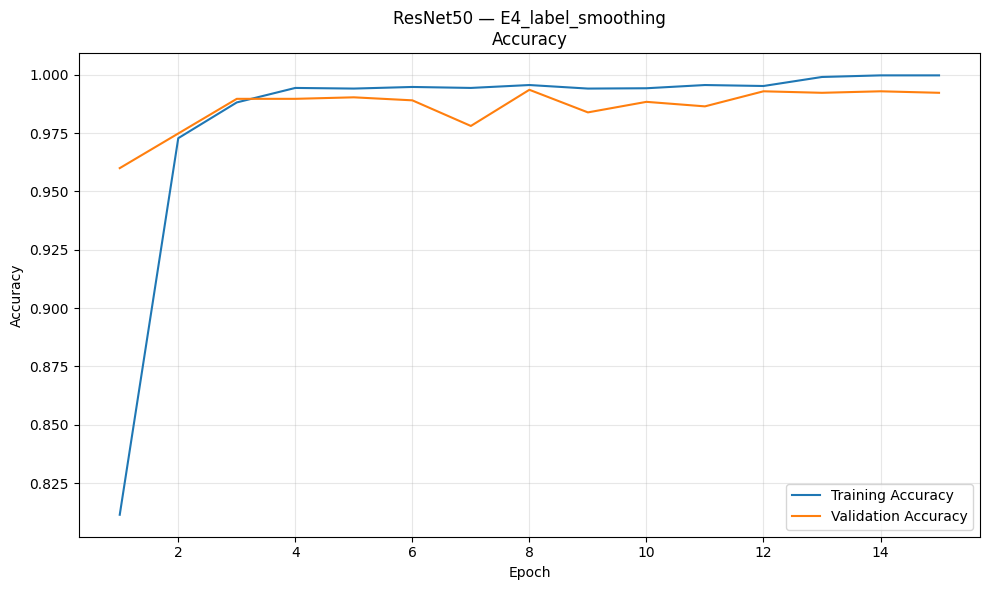

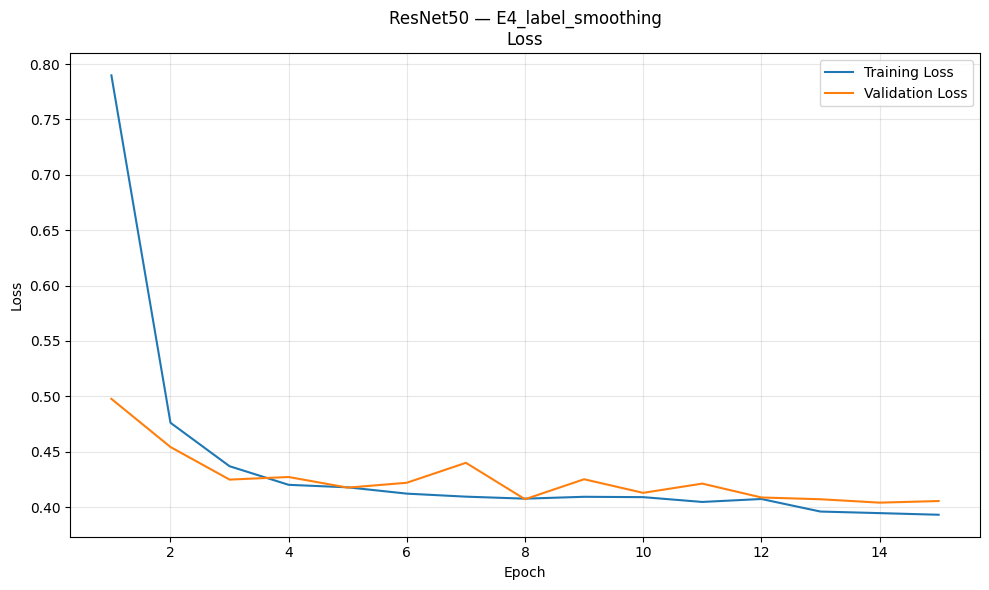

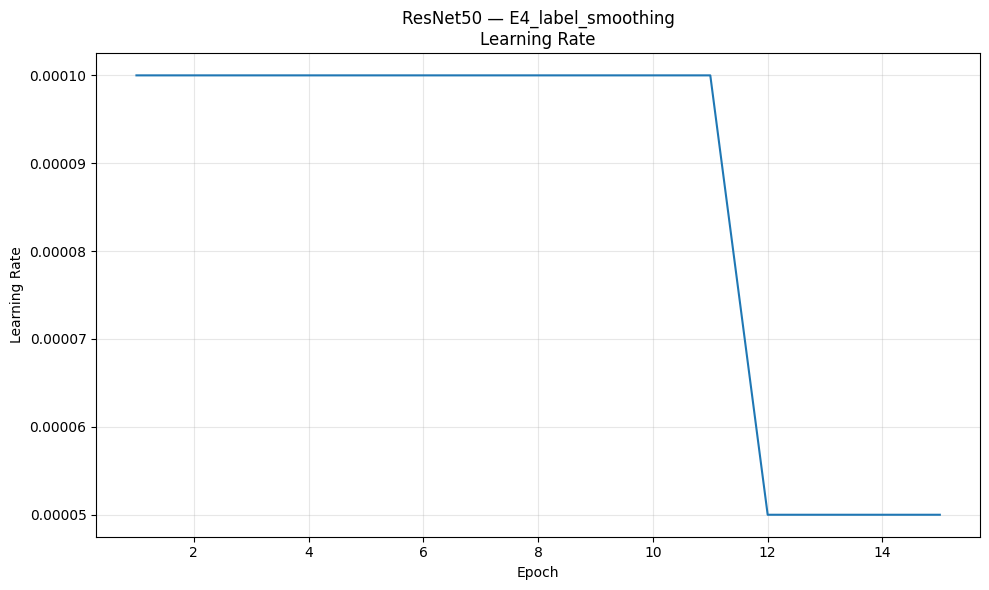

✓ Saved visualization for E4_label_smoothing


In [85]:
visualize_experiment(
    resnet50_e4_history,
    "ResNet50",
    "E4_label_smoothing",
    RESNET_EXP_DIR
)

In [86]:
resnet50_e4_overall = evaluate_model(
    resnet50_e4_model,
    test_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_e4_bd = evaluate_model(
    resnet50_e4_model,
    bd_test_complete_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_e4_int = evaluate_model(
    resnet50_e4_model,
    intl_test_complete_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — E4")
print("=" * 80)

print(
    f"Overall       : "
    f"{resnet50_e4_overall['accuracy']:.4%}"
)

print(
    f"Bangladesh    : "
    f"{resnet50_e4_bd['accuracy']:.4%}"
)

print(
    f"International : "
    f"{resnet50_e4_int['accuracy']:.4%}"
)

RESNET50 — E4
Overall       : 99.0395%
Bangladesh    : 97.9487%
International : 99.5345%


# ## #  RESNET50 — E5 HIGH RESOLUTION

In [87]:
# ============================================================
# RESNET50 — E5 HIGH RESOLUTION
# ============================================================

HIGH_RES = 256

highres_train_transform = transforms.Compose([

    transforms.Resize(
        (HIGH_RES, HIGH_RES)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

highres_eval_transform = transforms.Compose([

    transforms.Resize(
        (HIGH_RES, HIGH_RES)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

highres_train_dataset = WasteDataset(
    train_df,
    transform=highres_train_transform
)

highres_val_dataset = WasteDataset(
    val_df,
    transform=highres_eval_transform
)

highres_test_dataset = WasteDataset(
    test_df,
    transform=highres_eval_transform
)

highres_bd_dataset = WasteDataset(
    bd_test_complete,
    transform=highres_eval_transform
)

highres_int_dataset = WasteDataset(
    intl_test_complete,
    transform=highres_eval_transform
)

highres_train_loader = DataLoader(
    highres_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

highres_val_loader = DataLoader(
    highres_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

highres_test_loader = DataLoader(
    highres_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

highres_bd_loader = DataLoader(
    highres_bd_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

highres_int_loader = DataLoader(
    highres_int_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 80)
print("E5 — HIGH RESOLUTION READY")
print("=" * 80)

print(
    "Resolution:",
    HIGH_RES,
    "x",
    HIGH_RES
)

E5 — HIGH RESOLUTION READY
Resolution: 256 x 256


In [88]:
# ============================================================
# E5 TRAIN
# ============================================================

resnet50_e5_model, resnet50_e5_history, resnet50_e5_config = \
    train_experiment(

        model_name="resnet50",

        experiment_name="E5_high_resolution",

        train_loader_exp=highres_train_loader,

        val_loader_exp=highres_val_loader,

        epochs=30,

        lr=1e-4,

        weight_decay=1e-4,

        optimizer_type="adam",

        scheduler_type="plateau",

        label_smoothing=0.0
    )

print(
    "\n✓ RESNET50 E5 COMPLETE"
)


TRAINING: RESNET50 — E5_high_resolution
Epoch 01/30 | Train Loss: 0.5329 | Train Acc: 0.8123 | Val Loss: 0.1415 | Val Acc: 0.9529 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9529)
Epoch 02/30 | Train Loss: 0.1212 | Train Acc: 0.9604 | Val Loss: 0.0994 | Val Acc: 0.9613 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9613)
Epoch 03/30 | Train Loss: 0.0623 | Train Acc: 0.9816 | Val Loss: 0.1006 | Val Acc: 0.9774 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9774)
Epoch 04/30 | Train Loss: 0.0462 | Train Acc: 0.9872 | Val Loss: 0.0413 | Val Acc: 0.9897 | LR: 1.00e-04
  ✓ Best checkpoint saved (Val Acc: 0.9897)
Epoch 05/30 | Train Loss: 0.0346 | Train Acc: 0.9884 | Val Loss: 0.0560 | Val Acc: 0.9884 | LR: 1.00e-04
Epoch 06/30 | Train Loss: 0.0335 | Train Acc: 0.9910 | Val Loss: 0.0587 | Val Acc: 0.9864 | LR: 1.00e-04
Epoch 07/30 | Train Loss: 0.0314 | Train Acc: 0.9894 | Val Loss: 0.0479 | Val Acc: 0.9890 | LR: 1.00e-04
Epoch 08/30 | Train Loss: 0.0324 | Train Acc: 0.

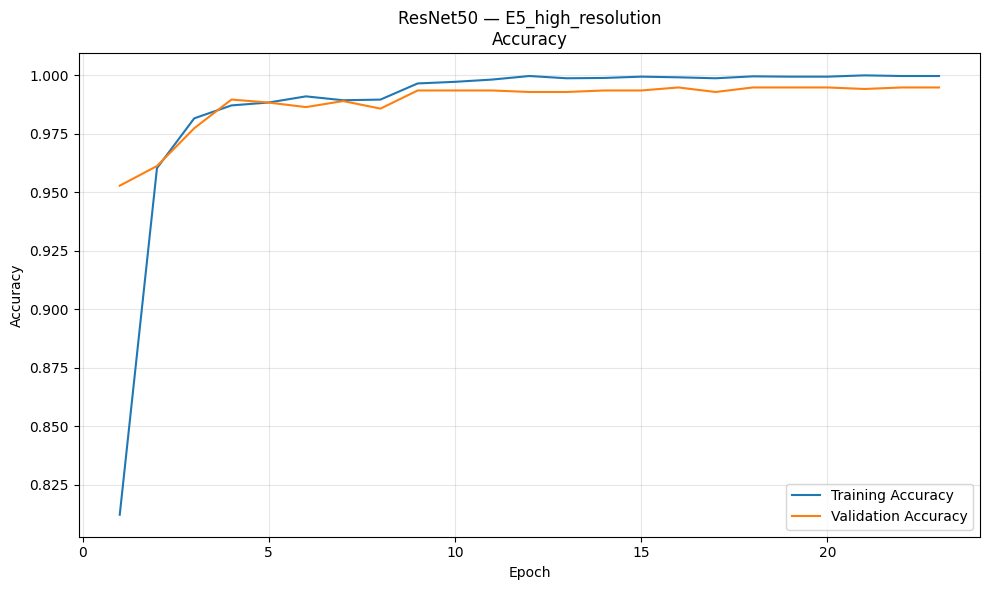

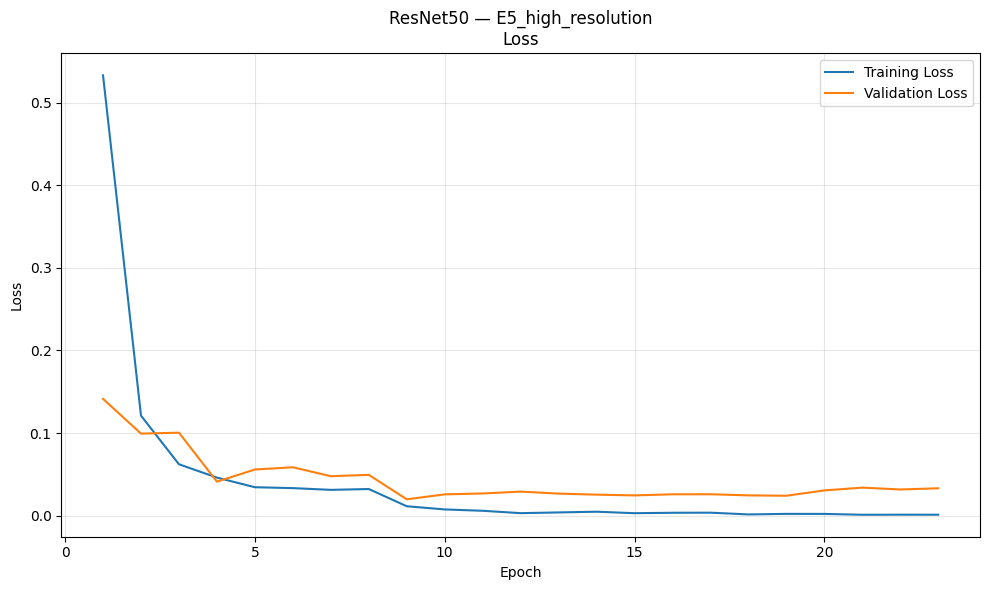

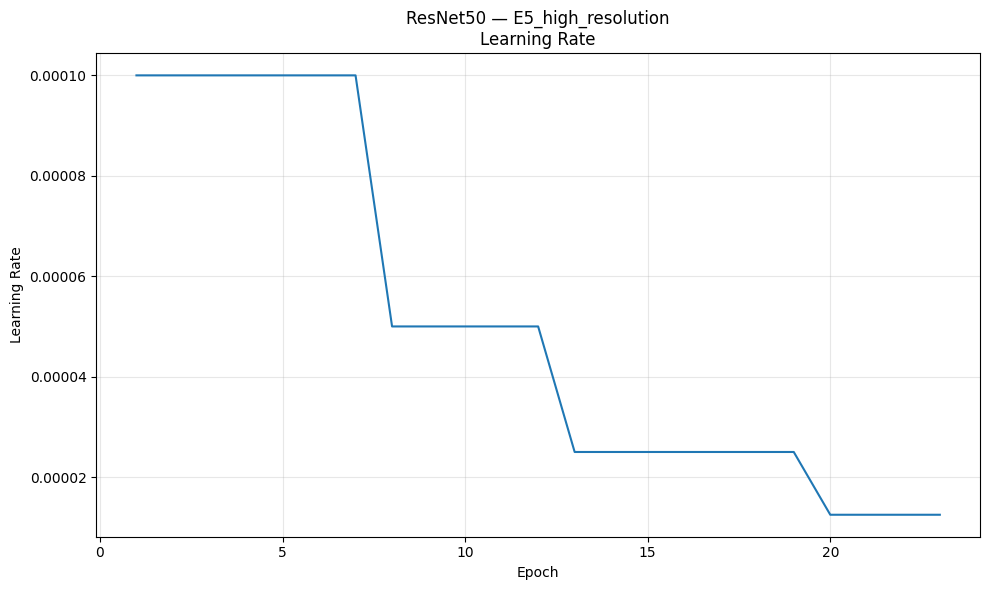

✓ Saved visualization for E5_high_resolution


In [89]:
visualize_experiment(
    resnet50_e5_history,
    "ResNet50",
    "E5_high_resolution",
    RESNET_EXP_DIR
)

In [90]:
resnet50_e5_overall = evaluate_model(
    resnet50_e5_model,
    highres_test_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_e5_bd = evaluate_model(
    resnet50_e5_model,
    highres_bd_loader,
    DEVICE,
    CLASS_NAMES
)

resnet50_e5_int = evaluate_model(
    resnet50_e5_model,
    highres_int_loader,
    DEVICE,
    CLASS_NAMES
)

print("=" * 80)
print("RESNET50 — E5")
print("=" * 80)

print(
    f"Overall       : "
    f"{resnet50_e5_overall['accuracy']:.4%}"
)

print(
    f"Bangladesh    : "
    f"{resnet50_e5_bd['accuracy']:.4%}"
)

print(
    f"International : "
    f"{resnet50_e5_int['accuracy']:.4%}"
)

RESNET50 — E5
Overall       : 99.1462%
Bangladesh    : 97.9487%
International : 99.6897%


# ## # #  E1 is overall perfect

# ## # # #  RESNET50 — COMPLETE EXPERIMENT COMPARISON

In [91]:
# ============================================================
# RESNET50 — COMPLETE EXPERIMENT COMPARISON
# ============================================================

resnet50_experiment_results = pd.DataFrame([

    {
        "Experiment": "E1 Baseline",
        "Validation Accuracy":
            resnet50_history["val_accuracy"].max(),
        "Overall Accuracy":
            resnet50_overall["accuracy"],
        "Bangladesh Accuracy":
            resnet50_bd_complete["accuracy"],
        "International Accuracy":
            resnet50_int_complete["accuracy"],
        "Overall F1":
            resnet50_overall["f1"]
    },

    {
        "Experiment": "E2 Strong Augmentation",
        "Validation Accuracy":
            resnet50_e2_history["val_accuracy"].max(),
        "Overall Accuracy":
            resnet50_e2_overall["accuracy"],
        "Bangladesh Accuracy":
            resnet50_e2_bd["accuracy"],
        "International Accuracy":
            resnet50_e2_int["accuracy"],
        "Overall F1":
            resnet50_e2_overall["f1"]
    },

    {
        "Experiment": "E3 AdamW + Cosine",
        "Validation Accuracy":
            resnet50_e3_history["val_accuracy"].max(),
        "Overall Accuracy":
            resnet50_e3_overall["accuracy"],
        "Bangladesh Accuracy":
            resnet50_e3_bd["accuracy"],
        "International Accuracy":
            resnet50_e3_int["accuracy"],
        "Overall F1":
            resnet50_e3_overall["f1"]
    },

    {
        "Experiment": "E4 Label Smoothing",
        "Validation Accuracy":
            resnet50_e4_history["val_accuracy"].max(),
        "Overall Accuracy":
            resnet50_e4_overall["accuracy"],
        "Bangladesh Accuracy":
            resnet50_e4_bd["accuracy"],
        "International Accuracy":
            resnet50_e4_int["accuracy"],
        "Overall F1":
            resnet50_e4_overall["f1"]
    },

    {
        "Experiment": "E5 High Resolution",
        "Validation Accuracy":
            resnet50_e5_history["val_accuracy"].max(),
        "Overall Accuracy":
            resnet50_e5_overall["accuracy"],
        "Bangladesh Accuracy":
            resnet50_e5_bd["accuracy"],
        "International Accuracy":
            resnet50_e5_int["accuracy"],
        "Overall F1":
            resnet50_e5_overall["f1"]
    }
])

display(
    resnet50_experiment_results.style.format(
        {
            "Validation Accuracy": "{:.4%}",
            "Overall Accuracy": "{:.4%}",
            "Bangladesh Accuracy": "{:.4%}",
            "International Accuracy": "{:.4%}",
            "Overall F1": "{:.4%}"
        }
    )
)

resnet50_experiment_results.to_csv(
    RESNET_EXP_DIR /
    "resnet50_experiment_comparison.csv",
    index=False
)

,Experiment,Validation Accuracy,Overall Accuracy,Bangladesh Accuracy,International Accuracy,Overall F1
0,E1 Baseline,99.4190%,99.4130%,98.8034%,99.6897%,99.4132%
1,E2 Strong Augmentation,99.3544%,98.2391%,95.3846%,99.5345%,98.2395%
2,E3 AdamW + Cosine,99.4835%,99.3597%,98.2906%,99.8448%,99.3596%
3,E4 Label Smoothing,99.3544%,99.0395%,97.9487%,99.5345%,99.0406%
4,E5 High Resolution,99.4835%,99.1462%,97.9487%,99.6897%,99.1467%


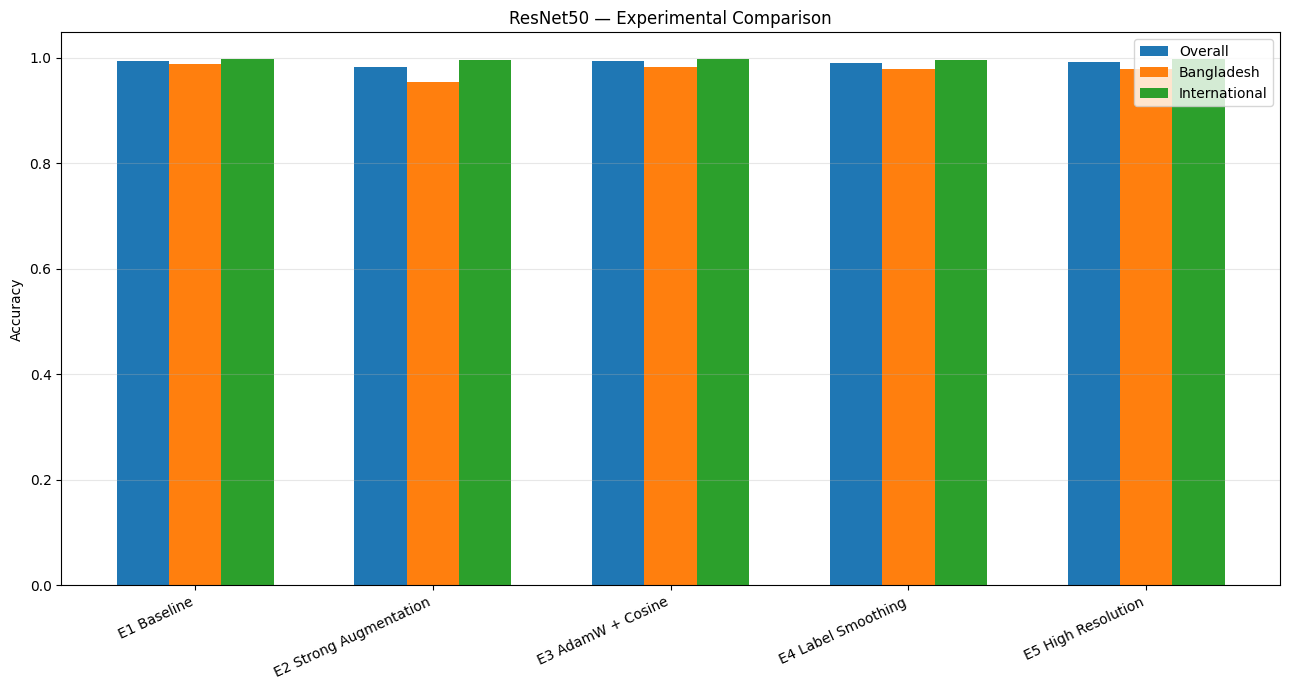

In [92]:
# ============================================================
# RESNET50 — EXPERIMENT COMPARISON CHART
# ============================================================

plot_df = resnet50_experiment_results.copy()

x = np.arange(
    len(plot_df)
)

width = 0.22

plt.figure(
    figsize=(13, 7)
)

plt.bar(
    x - width,
    plot_df["Overall Accuracy"],
    width,
    label="Overall"
)

plt.bar(
    x,
    plot_df["Bangladesh Accuracy"],
    width,
    label="Bangladesh"
)

plt.bar(
    x + width,
    plot_df["International Accuracy"],
    width,
    label="International"
)

plt.xticks(
    x,
    plot_df["Experiment"],
    rotation=25,
    ha="right"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "ResNet50 — Experimental Comparison"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESNET_EXP_DIR /
    "resnet50_experiment_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
# ============================================================
# RESNET50 — FINAL CHECKPOINT ARCHIVE
# DO NOT MODIFY ANY MODEL / DATA / CONFIG
# ============================================================

from pathlib import Path
import shutil
import os

SOURCE_DIR = Path(
    "/kaggle/working/waste_model_results/resnet50_experiments"
)

ARCHIVE_BASE = Path(
    "/kaggle/working/ResNet50_E1-E5_FINAL_CHECKPOINT"
)

print("=" * 80)
print("RESNET50 FINAL CHECKPOINT")
print("=" * 80)

print("Source:", SOURCE_DIR)

if not SOURCE_DIR.exists():
    raise FileNotFoundError(
        f"ResNet50 experiment directory not found: {SOURCE_DIR}"
    )

# Create archive
archive_path = shutil.make_archive(
    str(ARCHIVE_BASE),
    "zip",
    root_dir=SOURCE_DIR
)

print("\n✓ Archive created:")
print(archive_path)

# Check archive size
size_mb = os.path.getsize(archive_path) / (1024 ** 2)

print(f"✓ Archive size: {size_mb:.2f} MB")

print("\n✓ RESNET50 CHECKPOINT READY")
print("✓ Existing files were not modified.")
print("✓ Existing models were not retrained.")
print("✓ Existing inputs were not changed.")
print("✓ Existing outputs were not changed.")

RESNET50 FINAL CHECKPOINT
Source: /kaggle/working/waste_model_results/resnet50_experiments

✓ Archive created:
/kaggle/working/ResNet50_E1-E5_FINAL_CHECKPOINT.zip
✓ Archive size: 336.24 MB

✓ RESNET50 CHECKPOINT READY
✓ Existing files were not modified.
✓ Existing models were not retrained.
✓ Existing inputs were not changed.
✓ Existing outputs were not changed.


In [94]:
# ============================================================
# RESNET50 — FINAL FILE VERIFICATION
# READ ONLY
# ============================================================

from pathlib import Path

root = Path(
    "/kaggle/working/waste_model_results/resnet50_experiments"
)

print("=" * 80)
print("RESNET50 FINAL FILE CHECK")
print("=" * 80)

if not root.exists():
    print("❌ ResNet50 directory not found")
else:

    files = list(root.rglob("*"))

    files = [
        f for f in files
        if f.is_file()
    ]

    print(f"\nTotal files: {len(files)}")

    for f in sorted(files):
        size_mb = f.stat().st_size / (1024 ** 2)

        print(
            f"{f.relative_to(root)} "
            f"({size_mb:.2f} MB)"
        )

print("\n✓ Verification complete.")
print("✓ No files were modified.")

RESNET50 FINAL FILE CHECK

Total files: 29
E2_strong_augmentation/accuracy_curve.png (0.14 MB)
E2_strong_augmentation/classification_report.csv (0.00 MB)
E2_strong_augmentation/config.json (0.00 MB)
E2_strong_augmentation/confusion_matrix.png (0.15 MB)
E2_strong_augmentation/confusion_matrix_normalized.png (0.17 MB)
E2_strong_augmentation/history.csv (0.00 MB)
E2_strong_augmentation/learning_rate_curve.png (0.11 MB)
E2_strong_augmentation/loss_curve.png (0.14 MB)
E2_strong_augmentation/resnet50_best.pth (90.02 MB)
E3_adamw_cosine/accuracy_curve.png (0.15 MB)
E3_adamw_cosine/config.json (0.00 MB)
E3_adamw_cosine/history.csv (0.00 MB)
E3_adamw_cosine/learning_rate_curve.png (0.14 MB)
E3_adamw_cosine/loss_curve.png (0.13 MB)
E3_adamw_cosine/resnet50_best.pth (90.02 MB)
E4_label_smoothing/accuracy_curve.png (0.15 MB)
E4_label_smoothing/config.json (0.00 MB)
E4_label_smoothing/history.csv (0.00 MB)
E4_label_smoothing/learning_rate_curve.png (0.10 MB)
E4_label_smoothing/loss_curve.png (0.15 